# UK Biobank — Academic Impact I: Fields of Research (ANZSRC FoR 2020)

Where 20 years of UK Biobank publications sit inside the world literature, read through
the **ANZSRC 2020 Fields of Research** classification: how much UK Biobank publishes,
which fields it concentrates in, and how well that work is cited against everyone else
publishing in the same field in the same year.

**Two arms, one denominator.** Every number here compares two count tables built from one
file list: the **UK Biobank arm** (papers that use UK Biobank) and the **background arm**
(everything else Dimensions indexes). The two summed are the **whole database**, which is
the denominator for every share, index and ratio below. Nothing is compared against a
hand-picked control group.

**The size fact that governs every reading.** UK Biobank is a fraction of a percent of the
tagged literature (printed by §3). So a *share* of a field is small everywhere by
construction and mostly reproduces "which fields are big", and UK Biobank is far too small
to bend a whole-database curve — a rise after 2014 is a database-wide trend, not an effect.
The measures that survive this are the **activity index** (§4.5), the **relative citation
impact** (§5) and the **quality bands** (§6).

**Sections**

| § | question | output |
|---|---|---|
| 1 | Setup | environment, repo paths, shared `STYLE`, shared analysis module |
| 2 | Analysis parameters | every switch this run depends on, in one cell |
| 3 | Data layer | load both arms, run the guards, derive the analysis tables |
| 4 | **Volume** — how much, and where | Charts 1–4 + the marginal-growth table |
| 5 | **Citation impact** — how well it lands | Charts 5–8 |
| 6 | **Quality bands** — the cut-offs behind the percentiles | §6.1 + Charts 9, 9a, 9b, 10 |
| 7 | **Growth** — where UK Biobank is moving next | Chart 11 |

Chart numbers are stable: chart *n* saves as `0n_…` / `n_…` in `STYLE["savedir"]`, and the
same numbers are used in the sibling notebook.

> **Sibling notebook.** [`03_academic_impact_02_rcdc_analysis.ipynb`](03_academic_impact_02_rcdc_analysis.ipynb)
> runs this same analysis over the NIH **RCDC** disease/condition vocabulary. Everything the
> two must agree on — loading, guards, the activity index, the citation windows, the impact
> table — lives in `src/utils/data_analysis_03_academic_impact_analysis.py`; only the charts
> live in the notebooks, so a chart cell can be moved between them unchanged.


## 1. Setup

Imports, repo-anchored paths, and the shared plotting style.

* **Paths** — `shared_paths.bootstrap()` anchors every input/output on the repo root, so the
  notebook runs identically from the repo root, `src/`, or `src/data_analysis/`.
* **Style** — palette, font sizes and figure directory come from
  `universal_settings.yml` (`style.notebooks.03_academic_impact`), merged over the shared
  `base` by `load_style`, so every figure in this project draws from one file. `savefig`
  and `extended_palette` read the same registered `STYLE`.
* **Analysis module** — `data_analysis_03_academic_impact_analysis` (imported as `AI`) is
  the data layer shared with the RCDC notebook; see §3.


In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- project plotting style ------------------------------------------------------
# The palette, font sizes and output directory live in universal_settings.yml at the
# repo root (section style.notebooks.03_academic_impact) so every notebook draws from
# one file. load_style merges the shared `base` with this notebook's overrides,
# registers the result for savefig()/extended_palette() and pushes it into rcParams.
from utils.shared_style import (apply_style, extended_palette, load_style, savefig,
                                use_style, year_ticks)
STYLE = load_style("03_academic_impact")

# --- the analysis data layer -----------------------------------------------------
# Loading, guards, the activity index, the citation windows and the impact table are
# identical for both classification systems, so they live in one module that this
# notebook and its sibling share. Charts stay here; see the module docstring.
from utils import data_analysis_03_academic_impact_analysis as AI

print("palette:", STYLE["colors"])
print("figures ->", STYLE["savedir"], f"(save={STYLE['save']})")


palette: ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']
figures -> output/figures/data_analysis/03_academic_impact (save=False)


## 2. Analysis parameters

Every switch this run depends on, in one cell: which level of the vocabulary to compare on,
how a multi-labelled paper is counted, which citation measures lead, the guards, the year
window, and which pathway produced the counts. Nothing downstream hard-codes a choice made
here, and the cell prints the resulting configuration so any figure can be traced back to it.

**The vocabulary.** ANZSRC 2020 Fields of Research is a two-level hierarchy: `FOR_LEVEL="L4"`
compares fine fields (*4202 Epidemiology*), `"L2"` broad divisions (*42 Health Sciences*).
"Field" below always means a category at the level set here.

**Where the counts come from** (`SOURCE`):

* `"vm"` — counted row by row off the Dimensions corpus copy on BMRC by
  `src/utils/data_analysis_03_academic_impact_field_counts.py --category for`. A **fixed
  snapshot**, and the only pathway that can carry fractional counts and citation weights.
* `"api"` — the whole-database counts faceted straight out of the Dimensions API by
  `src/utils/data_analysis_03_academic_impact_dimensions_api.py`. Aggregates only, and the
  **live** index rather than the snapshot the UK Biobank arm came from.

Both arms always come off one file list, and everything downstream adapts rather than
breaks: measures only one arm carries are dropped (and said so), the activity index falls
back to whole counting when there is no fractional column, and the citation sections skip
themselves.

**Sibling notebook.** A guard fixed here is fixed in
[`03_academic_impact_02_rcdc_analysis.ipynb`](03_academic_impact_02_rcdc_analysis.ipynb)
too — the shared logic lives in `src/utils/data_analysis_03_academic_impact_analysis.py`.


In [2]:
COL_TYPE = "for"

# Which level of the hierarchy to compare on:
#   "L4" = fine field       (e.g. 4202 Epidemiology)
#   "L2" = broad division   (e.g. 42 Health Sciences)
FOR_LEVEL = "L4"

# FOR has no sub-vocabulary to slice; the RCDC notebook uses this to separate diseases
# from cross-cutting tags. Kept here so both notebooks share one build cell verbatim.
RCDC_VIEW = "all"

# The year UK Biobank publications begin in earnest (2013 has only a handful).
UKBB_YEAR = 2014

# How many of UK Biobank's OWN top fields to follow through the whole database.
TOP_N = 8

# Counting metric for the VOLUME charts:
#   "n_papers" = a paper counts once in EVERY field it carries (absolute)
#   "n_frac"   = its weight split evenly across its fields (per-level fractional)
# For FOR the two agree closely (UK Biobank carries 1.51 codes per paper, the database
# 1.42), unlike RCDC where a UK Biobank paper carries nearly twice the tags of an
# average one. Shares of a single field are absolute; anything comparing ACROSS fields
# uses the fractional columns regardless of this line.
WEIGHT = "n_papers"

# CITATION METRICS ------------------------------------------------------------
# Which citation quantities exist depends on how the counts were built; this run (API)
# carries four, and the loader prints the list it actually found:
#   "n_cit"     raw times_cited        — citation mass. Accrues with age, and is NOT
#                                        normalised by year, so it is used for SHARES
#                                        and descriptive means only — never as an
#                                        rci_ ratio. See RCI_WEIGHTS in the module.
#   "n_mncs"    times_cited / the mean of its own (year, field) — 1.0 = the field's
#                                        average paper that year. The headline.
#   "n_top10f"  1.0 if the paper is in the most-cited tenth OF ITS OWN (year, field),
#                                        against a cut-off MEASURED by counting
#                                        (dimensions_api.py deciles).
#   "n_top50f"  1.0 if it is at or above that (year, field)'s MEDIAN.
# The VM pathway carries "n_fcr" (Dimensions' own field citation ratio) and "n_top10"
# (the decile of the whole corpus rather than of the field) in place of the last two.
#
# NOT CARRIED ANY MORE: "n_top10p", the proxy that called a paper top-decile when its
# mncs cleared a K calibrated per (year, type). The `deciles` mode measures the real
# per-field cut-off now, so the proxy adds nothing — and it was the weight with the
# shortest usable window, which held the whole impact window back a year. The column is
# still written to the partials; the analysis module simply no longer reads it.
#
# CITE_HEADLINE   the intensity measure the impact map and the time panel lead with.
#                 A REQUEST, not a fact: if the run has no FCR (the API pathway does
#                 not) the loader substitutes n_mncs and says so.
# CITE_SHARE_METRIC  what Chart 7 tracks: UK Biobank's share of the world's ___ in a
#                 field. Set it to "n_papers" to see the volume baseline on the same
#                 axes, or "n_cit" for the share of the field's citations.
CITE_HEADLINE = "n_fcr"
CITE_SHARE_METRIC = "n_top10f"

# WHERE THE MEASURING FLOOR IS ------------------------------------------------
# The API job measures a (year, field) cut-off only where UK Biobank has at least this
# many papers in the cell — `percentiles --min-ukbb` in
# data_analysis_03_academic_impact_dimensions_api.py. It is written down here because the
# notebook's own per-year floor has to sit AT OR ABOVE it: a year-cell this notebook is
# willing to DRAW has to be one that was MEASURED, or the panel loses its left edge to
# cells that were never thresholded.
API_MIN_UKBB = 10

# A field-window with a handful of UK Biobank papers has a mean citation rate that is
# noise, so the impact measures drop anything thinner than these. The two floors below are
# not the same quantity and are not comparable to each other:
#
#   CITE_MIN_DOCS       pooled over the WHOLE impact window. The floor under a field's
#                       single RCI number in the IMPACT table (charts 5 and 6-left): how
#                       many UK Biobank papers in that field carried a citation value at
#                       all, summed across every year of the window.
#   CITE_MIN_DOCS_YEAR  within a SINGLE year. The floor under one cell of the RCI time
#                       series (chart 6, right), where a ratio of two means is at its
#                       noisiest, and the one that has to clear API_MIN_UKBB.
#
# 50 over an eleven-year window is about five papers a year, so it is a far weaker
# per-year condition than CITE_MIN_DOCS_YEAR — a pooled figure survives thin years, an
# individual year does not.
CITE_MIN_DOCS = 50       # over the whole impact window
CITE_MIN_DOCS_YEAR = 20  # within a single year; >= API_MIN_UKBB by construction
assert CITE_MIN_DOCS_YEAR >= API_MIN_UKBB, (
    f"CITE_MIN_DOCS_YEAR ({CITE_MIN_DOCS_YEAR}) is below the API's measuring floor "
    f"({API_MIN_UKBB}): the notebook would draw year-cells whose cut-offs were never "
    f"measured. Raise it, or re-measure with "
    f"`percentiles --min-ukbb {CITE_MIN_DOCS_YEAR}`.")

# How the usable citation window is derived (see the module for the reasoning):
#   a year needs CITE_COV_MIN of papers measured IN BOTH ARMS to be usable at all, and
#   the raw-citation weights then drop CITE_LAG further years, because a 2024 paper has
#   not been cited yet however completely it is indexed.
# The impact window is the INTERSECTION over every weight present, so the shortest one
# sets it: 2014-2023 here, held at 2023 by n_cit and the measured decile.
CITE_COV_MIN = 0.5
CITE_LAG = 1

# WHAT THE ACTIVITY INDEX IS MEASURED AGAINST ---------------------------------
# The index is a ratio of shares, so it depends entirely on what "the database" means:
#   "global"         every paper Dimensions indexes, art history included
#   "universe"       restricted to UNIVERSE_DIVISIONS below
#   "within_parent"  each L4 field against its own L2 division, both arms
#
# Worth knowing before choosing: "universe" divides EVERY field's index by one and the
# same constant (1.86 on this data — UK Biobank has 94% of its mass in those divisions
# against the database's 51%), so it re-ranks nothing; it only moves where parity sits.
# "within_parent" is the one that removes "UK Biobank is a biomedical resource" from
# the comparison per field, and it does re-rank: Public Health reads 3.3x globally and
# 0.9x within Health Sciences — against all research it looks like a speciality, against
# health research UK Biobank is slightly under-represented in it. Epidemiology 51x -> 14x.
ACTIVITY_BASE = "within_parent"
UNIVERSE_DIVISIONS = ("31", "32", "42", "52")   # bio, biomedical, health, psychology

# Analysis window. 2025-26 are dropped on purpose: the Dimensions index is still
# filling in for them, so their counts are not comparable and would fake a collapse.
YEAR_MIN = 2004
YEAR_MAX = 2024

BEFORE_WIN = (YEAR_MIN, UKBB_YEAR - 1)   # marginal-growth window before UK Biobank
AFTER_WIN  = (UKBB_YEAR, YEAR_MAX)       # marginal-growth window after

# LABEL QUALITY GUARD ---------------------------------------------------------
# A year where the background arm's category labels came back blank has no usable
# whole-database denominator, so any share computed from it is meaningless. Both
# guards are tripwires: with both arms counted from one snapshot they are currently
# inert, and that is exactly when they are worth keeping.
BLANK_MAX = 0.05
MASK_BAD_DENOM = True

# VOCABULARY SKEW GUARD -------------------------------------------------------
# A tag whose vocabulary changed between two snapshots has a real numerator and a
# near-empty denominator. Any field where UK Biobank exceeds this share of the world
# is that artefact, not a finding. None keeps them.
SKEW_MAX_SHARE = 5.0

# WHERE THE COUNTS COME FROM ---------------------------------------------------
# Two pathways produce the same tables, and both are kept because they answer
# different amounts of the question:
#
#   "vm"   counted row by row off the Dimensions corpus copy on BMRC by
#          data_analysis_03_academic_impact_field_counts.py. Slow to run, but it is a
#          FIXED SNAPSHOT and it can count anything a row contains — fractional counts,
#          citation weights, the top-decile indicator.
#   "api"  the whole-database counts faceted straight out of the Dimensions API by
#          data_analysis_03_academic_impact_dimensions_api.py — about twenty queries for
#          the whole year x field matrix. Aggregates only: no fractional column and no
#          citation weights, and it is the LIVE index rather than the snapshot the UK
#          Biobank arm came from.
#
# Everything downstream adapts rather than breaks: the loader drops any measure only one
# arm carries and says so, the activity index falls back to whole counting when there is
# no fractional column, and the citation sections skip themselves.
SOURCE = "api"

# WHERE THE PARTIALS LIVE ------------------------------------------------------
# One output directory holds every category's partials; they are named per-category,
# and the two pathways write the same filenames into different directories.
COUNTS_DIR = P.FOR_COUNTS if SOURCE == "vm" else P.FOR_COUNTS_API

print(f"source={SOURCE}   category={COL_TYPE}   level={FOR_LEVEL}   weight={WEIGHT}   top-N={TOP_N}")
print(f"citation: headline={CITE_HEADLINE}  share metric={CITE_SHARE_METRIC}")
print(f"window {YEAR_MIN}-{YEAR_MAX}   before={BEFORE_WIN}  after={AFTER_WIN}")


source=api   category=for   level=L4   weight=n_papers   top-N=8
citation: headline=n_fcr  share metric=n_top10f
window 2004-2024   before=(2004, 2013)  after=(2014, 2024)


## 3. Data layer — load both arms, run the guards, derive the analysis tables

One call does the whole data layer: resolve which partials belong to which arm, drop
blank-labelled years, build the whole-database denominator (= both arms summed), rank UK
Biobank's own top fields, compute the activity index, derive the usable citation window
from coverage, and build the per-field impact table.

**Read the printed output** — it says what was guarded against as it went, which is the
difference between "this field shrank" and "the classification got sparser that year". It
closes with UK Biobank's overall share of the database and its top `TOP_N` fields with
share and activity index side by side.

`globals().update()` is deliberate: it puts the frames into the notebook under their own
names (`whole_ts`, `TOP_CODES`, `IMPACT`, …), so a chart cell reads the same here as in the
RCDC notebook and can be moved between them unchanged. Everything it injects is listed in
`AI.build`'s docstring.


In [3]:
CTX = AI.build(
    COUNTS_DIR, COL_TYPE,
    level=FOR_LEVEL, rcdc_view=RCDC_VIEW,
    year_min=YEAR_MIN, year_max=YEAR_MAX, ukbb_year=UKBB_YEAR,
    top_n=TOP_N, weight=WEIGHT, palette=extended_palette,
    blank_max=BLANK_MAX, mask_bad_denom=MASK_BAD_DENOM,
    skew_max_share=SKEW_MAX_SHARE,
    cite_headline=CITE_HEADLINE, cite_min_docs=CITE_MIN_DOCS,
    cite_cov_min=CITE_COV_MIN, cite_lag=CITE_LAG,
    activity_base=ACTIVITY_BASE, universe_divisions=UNIVERSE_DIVISIONS,
)
globals().update(CTX)

# Bound to this run's guards, so a chart that has no whole-database series left to draw
# says so on the figure instead of drawing an empty axis.
flag_denominator = AI.denominator_flagger(STYLE, WHOLE_DB_OK, WHOLE_DB_MSG)

# FRAC_COL is n_frac when both arms carry fractional counts and n_papers when they do
# not (the API pathway) — the loader has already said which, and why.
_ukbb_overall = (ukbb[ukbb.year.between(*AFTER_WIN)][FRAC_COL].sum()
                 / whole[whole.year.between(*AFTER_WIN)][FRAC_COL].sum() * 100)
print(f"\nUK Biobank is {_ukbb_overall:.3f}% of the whole database over {AFTER_WIN[0]}-"
      f"{AFTER_WIN[1]} ({FRAC_COL}), so read\nthe activity index, not the share, for "
      f"where it concentrates.\n")
print(f"UK Biobank top {TOP_N} {SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}, by {VALUE}, "
      f"{UKBB_YEAR}+):\n")
for code, lab in zip(TOP_CODES, TOP_LABELS):
    tot = int(ukbb[ukbb.for_label == lab][VALUE].sum())
    ai = ACTIVITY.get(code, np.nan)
    print(f"  {AI.short(lab, 44):44s} UKBB {tot:>7,}   share@{YEAR_MAX} "
          f"{pct(share_at(lab), 2):>7s}   activity {ai:5.1f}x")
print(f"\n(activity index measured {ACTIVITY_LABEL} — ACTIVITY_BASE={ACTIVITY_BASE})")


loading for partials from /Users/valler/Python/RA/20_years_of_ukb/data/analysis/academic_impact/for_counts_api
  ukbb       1 partial(s), 526 rows, 103 fields, blank labels 0.0%
  background 1 partial(s), 2,052 rows, 171 fields, blank labels 0.0%
  !! CITE_HEADLINE=n_fcr is not in these partials; leading with n_mncs instead
     (mean-normalised citation score (field reference built by the count job))
  !! only one arm carries n_frac, n_cit_frac, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_recent, n_recent_frac, n_recent_docs, n_recent_docs_frac, n_mncs_frac, n_mncs_docs_frac, n_top10p_frac, n_top10p_docs_frac, n_top10f_frac, n_top10f_docs_frac, n_top50f_frac, n_top50f_docs_frac — dropped, because the whole-database
     total for a one-armed measure is just that arm again. Everything below uses
     n_papers where it would have used n_frac.
  measures: n_papers, n_cit, n_cit_docs, n_mncs, n_mncs_docs, n_top10p, n_top10p_docs, n_top10f, n_top10f_docs, n_top50f, n

## 4. Volume — how much UK Biobank publishes, and where it concentrates

Four charts and one table on paper counts alone, before any citation weighting. They move
from the raw trend towards the one volume measure that survives UK Biobank's size:

| | question | measure |
|---|---|---|
| Chart 1 | is this field growing, and how much of it is UK Biobank's? | yearly counts, stacked |
| Chart 2 | how much has UK Biobank added since it started publishing? | count, and share of the field |
| §4.3 | did the pace change before vs after `UKBB_YEAR`? | straight-line slope per window |
| Chart 3 | how fast is each field gaining papers, year by year? | first difference of Chart 1 |
| Chart 4 | what is UK Biobank *disproportionately* about? | activity index |

**Read Chart 4 before Chart 2's right panel.** The share is bounded by UK Biobank's size, so
it is small everywhere and mostly ranks fields by how big they are; the activity index
divides that size out and answers the question a funder is actually asking.


### 4.1 Chart 1 — Whole-database growth in UK Biobank's top fields

Small multiples, one panel per field. Each panel stacks the field's yearly papers into
**UK Biobank** vs **everyone else**, so both readings are available at once: the top of the
stack is the whole database's trend, and the coloured slice is UK Biobank's part of it.
That slice is small in absolute terms, so each panel is annotated with UK Biobank's share in
the final year. The dashed line marks the first UK Biobank year — **a time reference, not a
claimed cause**.

*Saves as* `01_whole_db_trends_…`


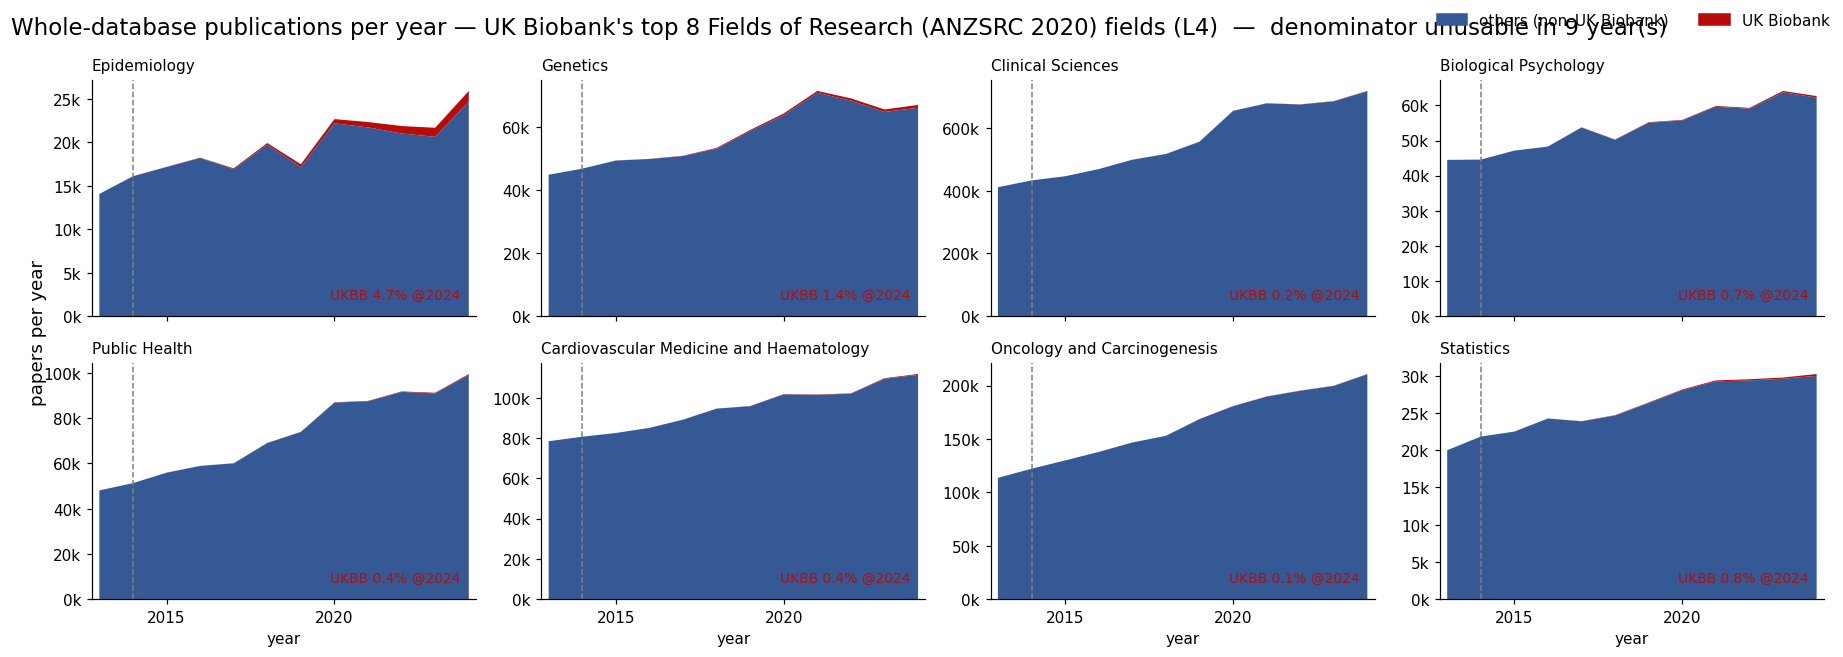

In [4]:
from matplotlib.patches import Patch

C_UKBB = STYLE["colors"][0]     # red  = UK Biobank
C_REST = STYLE["colors"][3]     # blue = everyone else
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")   # 25371 -> "25k"

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    yrs = whole_ts.index.values
    ukb = ukbb_ts[lab].reindex(whole_ts.index).fillna(0.0).values
    rest = whole_ts[lab].values - ukb
    ax.stackplot(yrs, rest, ukb, colors=[C_REST, C_UKBB])
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.set_ylim(bottom=0)
    ax.margins(x=0.02)
    ax.annotate(f"UKBB {pct(share_at(lab))} @{YEAR_MAX}",
                xy=(0.96, 0.06), xycoords="axes fraction", ha="right", va="bottom",
                fontsize=STYLE["annot_fs"], color=C_UKBB)
# One tick set for all the panels (they share an x-axis), anchored on the LAST year so
# the series is not read as ending at whatever the step happened to land on.
axes[0].set_xticks(year_ticks(whole_ts.index.min(), whole_ts.index.max(), 5))
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:      # x-label only on the bottom row that exists
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.legend(handles=[Patch(color=C_REST, label="others (non–UK Biobank)"),
                    Patch(color=C_UKBB, label="UK Biobank")],
           loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
fig.suptitle(f"Whole-database publications per year — UK Biobank's top {TOP_N} "
             f"{SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("papers per year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"01_whole_db_trends_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

### 4.2 Chart 2 — What UK Biobank adds, in papers and in share

* **Left** — UK Biobank's own output in each field (absolute count).
* **Right** — that output as a **share of the whole database** in the same field.

UK Biobank is a small slice of a vast literature, so the share is the truer measure of its
footprint than the raw count. Fields are direct-labelled on both panels, and colour follows
the field across the whole notebook.

The left panel comes from the UK Biobank arm alone, so it stays readable even when the
background arm has no usable labels and the right panel is stamped out by the guard.

*Saves as* `02_ukbb_contribution_…`


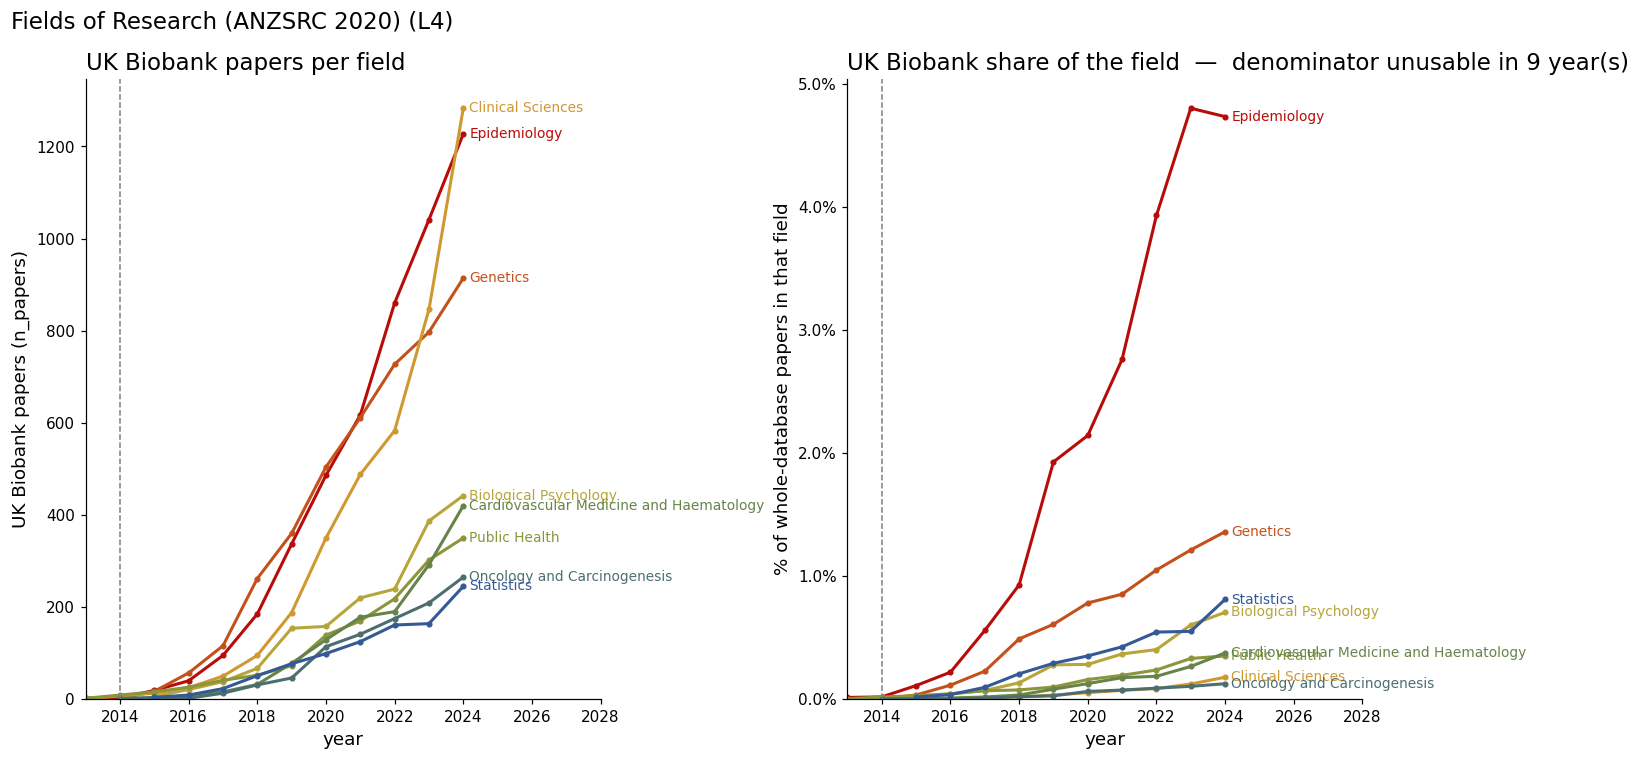

In [ ]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"])

for lab in TOP_LABELS:
    col = FIELD_COLORS[lab]
    axL.plot(ukbb_ts.index, ukbb_ts[lab], color=col, lw=2, marker="o", ms=3)
    axR.plot(share_ts.index, share_ts[lab], color=col, lw=2, marker="o", ms=3)
    yl = ukbb_ts[lab].dropna()
    if len(yl):
        axL.annotate(lab, (yl.index[-1], yl.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")
    yr = share_ts[lab].dropna()
    if len(yr):
        axR.annotate(lab, (yr.index[-1], yr.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")

for ax in (axL, axR):
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_xlabel("year")
    ax.set_ylim(bottom=0)
    ax.set_xlim(UKBB_YEAR - 1, YEAR_MAX + 4)       # room for the direct labels
axL.set_title(f"UK Biobank papers per {UNIT}", loc="left", fontsize=STYLE["title_fs"])
axL.set_ylabel(f"UK Biobank papers ({VALUE})")
axR.set_title(f"UK Biobank share of the {UNIT}{DENOM_NOTE}", loc="left",
              fontsize=STYLE["title_fs"])
axR.set_ylabel(f"% of whole-database papers in that {UNIT}")
# Pick the tick precision from the data: RCDC shares sit below 2%, and a 0-decimal
# formatter would render every tick as "0%" or "1%".
_smax = float(np.nanmax(share_ts.values)) if share_ts.notna().any().any() else 1.0
_nd = 0 if _smax >= 10 else (1 if _smax >= 1 else 2)
axR.yaxis.set_major_formatter(mticker.StrMethodFormatter(f"{{x:.{_nd}f}}%"))
#flag_denominator(axR)
fig.suptitle(f"{SYSTEM} ({LEVEL}{VIEW_NOTE})", fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"02_ukbb_contribution_{COL_TYPE}_{LEVEL}{FILE_TAG}_{WEIGHT}")
plt.show()

### 4.3 Marginal annual increase — before vs after UK Biobank *(table)*

**Marginal speed** = the slope (papers **added** per year) of a straight-line fit to the
yearly counts, measured separately in the before- and after-windows (`BEFORE_WIN`,
`AFTER_WIN`). It is fitted on the **whole database** (the secular trend) and, for context,
on UK Biobank's own output.

> **Caution.** UK Biobank is far too small — a fraction of a percent of any field — to bend
> the whole-database slope, so any acceleration in the `whole_*` columns is a **database-wide
> trend, not something UK Biobank caused**. The `ukbb_after` column is UK Biobank's own pace.
> `whole_*` comes back `<NA>` where the masking guard left that window empty.

**Read `activity_x` before `ukbb_share_%`.** The share answers "how much of this field is UK
Biobank?" and is bounded by UK Biobank's size, so it is small everywhere by construction. The
activity index answers "how much **more** of UK Biobank's work is in this field than the
literature's?" — 1.0 is parity, 3.0 is triple concentration — and that is the question a
funder is actually asking.


In [6]:
def slope(frame, code, win, value=VALUE):
    y0, y1 = win
    s = (frame[(frame.code == code) & frame.year.between(y0, y1)]
         .groupby("year")[value].sum()
         .reindex(range(y0, y1 + 1)).fillna(0.0))
    if (s > 0).sum() < 2:
        return np.nan
    return float(np.polyfit(s.index.values.astype(float), s.values, 1)[0])

rows = []
for code, lab in zip(TOP_CODES, TOP_LABELS):
    wb = slope(whole, code, BEFORE_WIN)
    wa = slope(whole, code, AFTER_WIN)
    accel = wa / wb if (not np.isnan(wb) and not np.isnan(wa) and wb > 0) else np.nan
    rows.append({
        UNIT: lab,
        "whole_before_/yr": wb,
        "whole_after_/yr": wa,
        "acceleration_x": accel,
        "ukbb_after_/yr": slope(ukbb, code, AFTER_WIN),
        f"ukbb_share@{YEAR_MAX}_%": share_at(lab),
        "activity_x": float(ACTIVITY.get(code, np.nan)),
    })

speed = pd.DataFrame(rows).set_index(UNIT)
speed_fmt = speed.copy()
for c in ["whole_before_/yr", "whole_after_/yr", "ukbb_after_/yr"]:
    speed_fmt[c] = speed_fmt[c].round(0).astype("Int64")
speed_fmt["acceleration_x"] = speed_fmt["acceleration_x"].round(2)
speed_fmt[f"ukbb_share@{YEAR_MAX}_%"] = speed_fmt[f"ukbb_share@{YEAR_MAX}_%"].round(2)
speed_fmt["activity_x"] = speed_fmt["activity_x"].round(2)
speed_fmt

,whole_before_/yr,whole_after_/yr,acceleration_x,ukbb_after_/yr,ukbb_share@2024_%,activity_x
field,,,,,,
Epidemiology,<NA>,831,NaN,127,4.73,11.89
Genetics,<NA>,2511,NaN,99,1.36,6.25
Clinical Sciences,<NA>,31910,NaN,114,0.18,0.85
Biological Psychology,<NA>,1901,NaN,44,0.71,2.41
Public Health,<NA>,5038,NaN,34,0.35,0.90
Cardiovascular Medicine and Haematology,<NA>,3165,NaN,38,0.38,1.76
Oncology and Carcinogenesis,<NA>,9178,NaN,27,0.13,0.75
Statistics,<NA>,920,NaN,23,0.81,6.72


### 4.4 Chart 3 — Growth speed of each field, year by year

**Speed** = the annual increase: how many more papers a field gained than the year before
(the first difference of Chart 1's whole-database curve). It is plotted **across** years, per
field, rather than collapsed into a single before/after number (§4.3), so the change in pace
is shown descriptively rather than as a story about a cause.

The dashed line at `UKBB_YEAR` is **only a time reference**: a rise to its right is a
database-wide trend, and UK Biobank — single-digit percent of any field at most — is far too
small to have bent these curves.

*Saves as* `03_growth_speed_…`


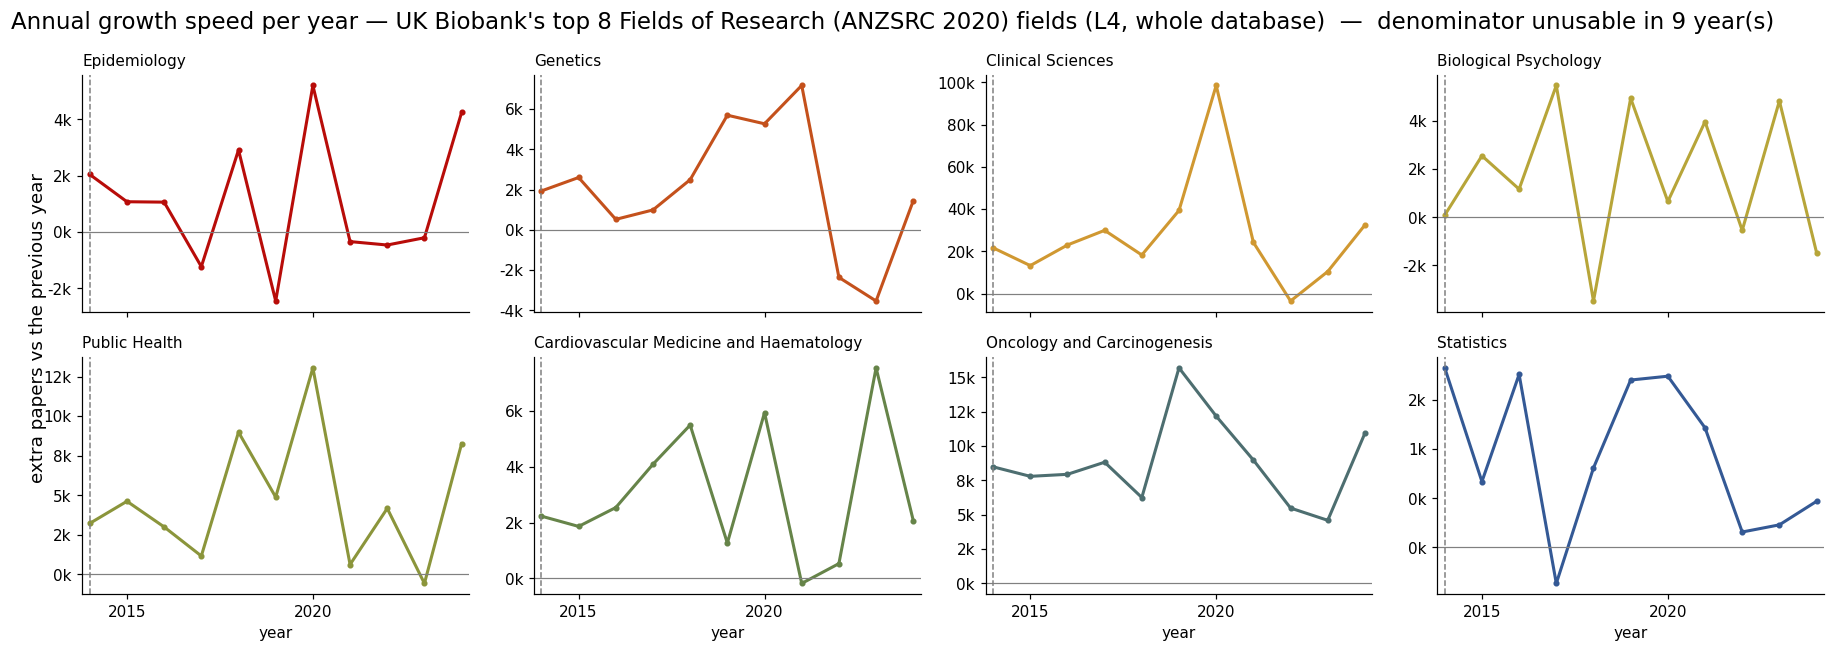

In [7]:
speed_ts = whole_ts.diff()      # papers gained vs the previous year
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    s = speed_ts[lab].dropna()
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ax.axhline(0, color=STYLE["edgecolor"], lw=0.8)
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.margins(x=0.02)
# One tick set for all the panels (they share an x-axis), anchored on the LAST year so
# the series is not read as ending at whatever the step happened to land on.
axes[0].set_xticks(year_ticks(speed_ts.dropna(how='all').index.min(), speed_ts.dropna(how='all').index.max(), 5))
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.suptitle(f"Annual growth speed per year — UK Biobank's top {TOP_N} {SYSTEM} "
             f"{UNIT}s ({LEVEL}{VIEW_NOTE}, whole database){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("extra papers vs the previous year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"03_growth_speed_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

### 4.5 Chart 4 — The activity index: what UK Biobank is disproportionately about

Chart 2's share is bounded by UK Biobank's size, so every field looks tiny there and the
ranking mostly reproduces "which fields are big". The activity index divides that size out:

$$\text{AI}(X)=\frac{\text{UK Biobank's papers in }X\ /\ \text{all UK Biobank papers}}
{\text{database's papers in }X\ /\ \text{all database papers}}$$

**1.0** = UK Biobank works on *X* exactly as much as the literature does, **3.0** = three
times as concentrated, **0.3** = a third. It is a *ratio of shares*, so it is computed on
`n_frac` whatever `WEIGHT` says — the same convention as `ACTIVITY` in the §3 build cell —
and it is measured against whatever `ACTIVITY_BASE` sets (see §2: `within_parent` is the one
that removes "UK Biobank is a biomedical resource" from the comparison).

* **Left** — UK Biobank's biggest fields against parity. Log axis, so 2× and 0.5× sit the
  same distance from the 1.0 line; dot area = UK Biobank papers, so a large dot far to the
  right is both a big and a distinctive body of work.
* **Right** — the same index year by year: is the concentration deepening or fading?
  Field-years carrying fewer than `ACT_MIN_N` UK Biobank papers are dropped — a ratio of
  shares built on a handful of papers is noise, which is most of what the first two years
  after `UKBB_YEAR` contain.

*Saves as* `04_activity_index_…`


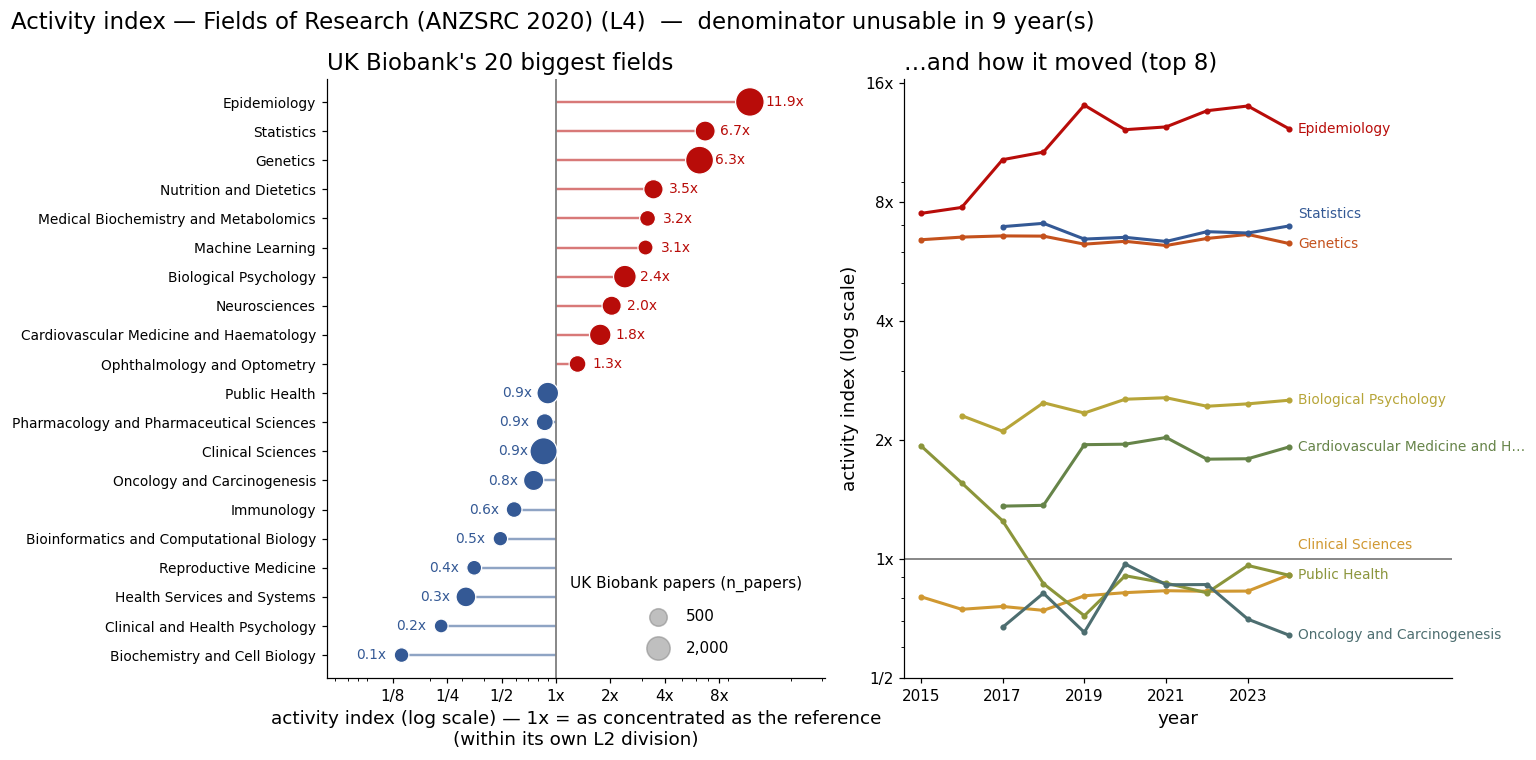

activity index over 2014-2024, UK Biobank's top 20 fields (>1 = over-represented vs the whole database):

  Epidemiology                                          11.89x     4,910 papers
  Statistics                                             6.72x       958 papers
  Genetics                                               6.25x     4,366 papers
  Nutrition and Dietetics                                3.47x       807 papers
  Medical Biochemistry and Metabolomics                  3.22x       283 papers
  Machine Learning                                       3.14x       218 papers
  Biological Psychology                                  2.41x     1,732 papers
  Neurosciences                                          2.04x       785 papers
  Cardiovascular Medicine and Haematology                1.76x     1,347 papers
  Ophthalmology and Optometry                            1.32x       394 papers
  Public Health                                          0.90x     1,396 papers
  Pharmacology

In [8]:
ACT_TOP_M = 20      # how many of UK Biobank's biggest categories to rank (left)
ACT_MIN_N = 10      # min UK Biobank papers in a category-year to plot it (right)

C_ABOVE, C_BELOW = STYLE["colors"][0], STYLE["colors"][3]   # red over, blue under

# -- left panel data: UK Biobank's ACT_TOP_M biggest categories, ranked by index ----
_rank_m = (ukbb[ukbb.year >= UKBB_YEAR].groupby(["code", "for_label"])[VALUE].sum()
           .sort_values(ascending=False).head(ACT_TOP_M))
act_tbl = (pd.DataFrame({"label": [lab for _, lab in _rank_m.index],
                         "ukbb": _rank_m.to_numpy(),
                         "activity": [ACTIVITY.get(c, np.nan) for c, _ in _rank_m.index]})
           .dropna(subset=["activity"]).sort_values("activity").reset_index(drop=True))

# -- right panel data: the index recomputed within each year ------------------------
# Both arms are re-shared within each year, so a year in which the whole database grew
# does not move the index; only a change in its COMPOSITION does.
# It goes through activity_index() rather than re-deriving the shares here, because the
# BASE has to be ACTIVITY_BASE — the one the left panel, the axis label and every
# printed number already use. Re-sharing over all codes inline is the global index, and
# under ACTIVITY_BASE="within_parent" that is a different number entirely: Epidemiology
# is 11.9x within its own division and 62x against all research, so the two panels
# would disagree by a factor of five under one shared title.
# activity_index() follows FRAC_COL by itself, so the fallback to whole counting when
# the partials carry no fractional column (the API pathway) still holds here.
act_ts = pd.DataFrame({y: activity_index((y, y))
                       for y in sorted(whole.year.unique())}).T.sort_index()
_u_year = ukbb.pivot_table(index="year", columns="code", values=FRAC_COL, aggfunc="sum")
act_ts = act_ts.where(_u_year.reindex(index=act_ts.index, columns=act_ts.columns)
                      >= ACT_MIN_N)
act_ts = act_ts.reindex(columns=TOP_CODES).set_axis(TOP_LABELS, axis=1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"],
                               gridspec_kw={"width_ratios": [1, 1.1]})

# ---- left: ranked lollipop against parity ----------------------------------------
ypos = np.arange(len(act_tbl))
colors = [C_ABOVE if a >= 1 else C_BELOW for a in act_tbl.activity]
sizes = 30 + 320 * np.sqrt(act_tbl.ukbb / act_tbl.ukbb.max())
axL.hlines(ypos, 1.0, act_tbl.activity, color=colors, lw=1.6, alpha=0.55)
axL.scatter(act_tbl.activity, ypos, s=sizes, color=colors, zorder=3,
            edgecolor="white", linewidth=0.8)
axL.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
for y, a in zip(ypos, act_tbl.activity):
    left = a < 1.0
    axL.annotate(f"{a:.1f}x", (a, y), fontsize=STYLE["annot_fs"],
                 color=C_BELOW if left else C_ABOVE, va="center",
                 ha="right" if left else "left",
                 xytext=(-10 if left else 10, 0), textcoords="offset points")
axL.set_xscale("log")
axL.set_xticks([0.125, 0.25, 0.5, 1, 2, 4, 8])
axL.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:g}x" if x >= 1 else f"1/{1 / x:g}"))
axL.xaxis.set_minor_formatter(mticker.NullFormatter())
axL.set_xlim(act_tbl.activity.min() / 2.6, act_tbl.activity.max() * 2.6)
axL.set_yticks(ypos)
axL.set_yticklabels([short(lab) for lab in act_tbl.label], fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.8, len(act_tbl) - 0.2)
axL.set_xlabel(f"activity index (log scale) — 1x = as concentrated as the reference\n({ACTIVITY_LABEL})")
axL.set_title(f"UK Biobank's {len(act_tbl)} biggest {UNIT}s", loc="left",
              fontsize=STYLE["title_fs"])

# Dot area is a second encoding on this panel, so it needs its own key.
_legend_n = [n for n in (500, 2000, 5000) if n <= act_tbl.ukbb.max()]
axL.legend(handles=[plt.scatter([], [], s=30 + 320 * np.sqrt(n / act_tbl.ukbb.max()),
                                color=STYLE["edgecolor"], alpha=0.5,
                                label=f"{n:,}") for n in _legend_n],
           title=f"UK Biobank papers ({VALUE})", loc="lower right", frameon=False,
           labelspacing=1.1, borderpad=1.0, fontsize=STYLE["legend_fs"],
           title_fontsize=STYLE["legend_fs"])

# ---- right: the index year by year ------------------------------------------------
ends = []                       # (final value, final year, label) for the direct labels
for lab in TOP_LABELS:
    s = act_ts[lab].dropna()
    if not len(s):
        continue
    axR.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))
axR.axhline(1.0, color=STYLE["edgecolor"], lw=1.2)

# Direct labels rather than a legend box, but several series finish within a few
# percent of each other; nudge them apart in log space so none is unreadable.
_lo = min(v for v, _, _ in ends) if ends else 0.5
_hi = max(v for v, _, _ in ends) if ends else 2.0
_gap = 0.045 * (np.log10(_hi / _lo) + 0.4)
_prev = None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (xend, 10 ** ly), color=FIELD_COLORS[lab],
                 fontsize=STYLE["annot_fs"], va="center",
                 xytext=(6, 0), textcoords="offset points")

axR.set_yscale("log")
# Log majors are decades and the whole index lives inside one decade — put the ticks
# on the doublings instead, so the reader can tell 2x from 4x.
_ticks = [t for t in (0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32) if _lo / 1.6 <= t <= _hi * 1.6]
axR.set_yticks(_ticks)
axR.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda y, _: f"{y:g}x" if y >= 1 else f"1/{1 / y:g}"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
_years = act_ts.dropna(how="all").index
_y0 = int(_years.min()) if len(_years) else UKBB_YEAR
axR.set_xlim(_y0 - 0.4, YEAR_MAX + 4)        # room for the direct labels
axR.set_xticks(year_ticks(_y0, YEAR_MAX, 2))
axR.set_xlabel("year")
axR.set_ylabel("activity index (log scale)")
axR.set_title(f"…and how it moved (top {TOP_N})", loc="left",
              fontsize=STYLE["title_fs"])
flag_denominator(axR)

fig.suptitle(f"Activity index — {SYSTEM} ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"04_activity_index_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

print(f"activity index over {AFTER_WIN[0]}-{AFTER_WIN[1]}, UK Biobank's top "
      f"{len(act_tbl)} {UNIT}s (>1 = over-represented vs the whole database):\n")
for _, r in act_tbl.iloc[::-1].iterrows():
    print(f"  {short(r.label, 52):52s} {r.activity:6.2f}x   {int(r.ukbb):>7,} papers")


## 5. Citation impact — how well that work lands

Volume answered "how much"; this part asks whether UK Biobank's papers are cited more than
the world's papers in the same field and year. Three citation weights are carried through
side by side, because a result that only holds under one of them is a property of the
measure rather than of UK Biobank:

| weight | what it is | what it rewards |
|---|---|---|
| `n_cit` | raw `times_cited` | citation mass — accrues with age, and with citation-heavy fields. **Shares and means only:** it is not year-normalised, so it never becomes an `rci_` ratio (see below) |
| `n_mncs` | `times_cited` ÷ the mean of its own (year, field) | 1.0 = the field's average paper that year. The headline on this run |
| `n_top10f` | top-decile indicator, **per field** | 1.0 if the paper is in the most-cited tenth of its own (year, field), against a cut-off measured by counting |
| `n_top50f` | above-median indicator, per field | 1.0 if it is at or above that (year, field)'s median |
| `n_fcr` | `field_citation_ratio` | field- **and** year-normalised; 1.0 = world average. VM pathway only |
| `n_top10` | top-decile indicator, whole corpus | VM pathway's decile: the most-cited tenth of the (year, type), not of the field |

**Why `n_cit` gets no ratio.** `rci_<w>` pools the whole impact window before taking the two
means, and the arms are not spread over that window alike: UK Biobank's output is still
ramping, so over 2014–2023 **76–86%** of its papers in its top fields are from the last four
years, against **44–49%** of the world's. A weight that accrues with age therefore meets a far
younger population in the numerator than in the denominator, and the ratio comes out too low —
pooled **1.83** against a year-controlled **2.15** for Epidemiology, and **1.90** against
**2.66** for Biological Psychology. Every weight that *does* carry a ratio is normalised
against its own publication year **before** it is aggregated, so the composition cancels.
`n_cit` stays available as a *share* (Chart 7), where numerator and denominator are the same
set of papers and the problem does not arise.

`CITE_HEADLINE` (§2) picks the one the headline panels lead with; `CITE_MIN_DOCS` /
`CITE_MIN_DOCS_YEAR` set how thin a field-window may be before its mean is treated as noise,
and the usable citation window is derived from coverage in §3. §5.1 builds the table, §§5.2–5.5
draw it.


### 5.1 The citation-weighted table — `IMPACT`

`IMPACT` (built in the §3 load cell) carries, per field, over the impact window:

* **`rci_<w>` — relative citation impact.** The mean weight of UK Biobank's papers in *X*
  over the mean weight of the whole database's papers in *X*. **1.0 = cited exactly like
  everyone else's work in the same field.** It is a *mean* over the papers that carried a
  value, which is what lets it survive the two arms being measured to different depths (on
  the VM pathway FCR reaches 97% of the UK Biobank arm and 73% of the background; on this
  one every weight is measured in ~100% of both). Only the weights in `RCI_WEIGHTS` get
  one — `n_cit` does not, for the reason in §5.
* **`act_<w>` — citation activity index.** Chart 4's activity index with citation mass in
  place of paper counts; folds volume and impact together.
* **`activity_x`** — the volume activity index recomputed on the impact window, so all the
  columns describe the same years.

**The pooled figure comes first, deliberately.** Without it a field's 2.5× reads as
remarkable when the whole corpus sits at 2.4× and the field is merely average *for UK
Biobank*.


In [9]:
if not CITE_OK:
    print("no usable citation window — the impact section is skipped")
else:
    _u = ukbb[ukbb.year.between(*CITE_WIN)]
    _w = whole[whole.year.between(*CITE_WIN)]
    # FRAC_SFX is "_frac" on the VM pathway and "" on the API one, where there are no
    # fractional columns to take a mean over — same measure either way.
    _mean = lambda f, wt: f[f"{wt}{FRAC_SFX}"].sum() / f[f"{wt}_docs{FRAC_SFX}"].sum()
    print(f"UK Biobank overall, {CITE_WIN[0]}-{CITE_WIN[1]}, against the whole database"
          f" ({UNIT}-tagged papers):")
    # Every weight gets its two means printed; only the year-normalised ones get the
    # ratio beside them. n_cit's means are worth seeing — they are the arithmetic
    # everything else is built on — but their quotient would compare UK Biobank's
    # recent papers with the world's older ones, so it is withheld rather than shown
    # with a caveat nobody reads. RCI_WEIGHTS is the list that may be divided.
    for wt in WEIGHTS_PRESENT:
        label = {"n_cit": "citations per paper", "n_fcr": "field citation ratio",
                 "n_top10": "share in the top decile",
                 "n_top10f": "share in the field's top decile",
                 "n_top50f": "share above the field median",
                 "n_mncs": "citations vs the field average"}.get(wt, wt)
        fmt = "{:.1%}" if wt.startswith("n_top") else "{:.2f}"
        ratio = (f"= {OVERALL[wt[2:]]:.2f}x" if wt in RCI_WEIGHTS
                 else "(no ratio — not year-normalised)")
        print(f"  {label:31s} UKBB {fmt.format(_mean(_u, wt)):>7s}   whole "
              f"{fmt.format(_mean(_w, wt)):>7s}   {ratio}")

    _head = CITE_HEADLINE[2:]
    cols = (["ukbb_papers", "activity_x"] + [f"rci_{w[2:]}" for w in RCI_WEIGHTS]
            + [f"act_{_head}"])
    impact_fmt = (IMPACT.loc[TOP_CODES, cols]
                  .rename(index=dict(zip(TOP_CODES, TOP_LABELS))).round(2))
    impact_fmt["ukbb_papers"] = impact_fmt.ukbb_papers.round(0).astype("Int64")
    impact_fmt.index.name = UNIT
    print(f"\nUK Biobank's top {TOP_N} {UNIT}s — volume beside impact "
          f"({CITE_WIN[0]}-{CITE_WIN[1]}, {'fractional' if FRAC_OK else 'whole'} counts):")
    display(impact_fmt)


UK Biobank overall, 2014-2022, against the whole database (field-tagged papers):
  citations per paper      UKBB   58.21   whole   17.60   = 3.31x
  share in the field's top decile UKBB   30.3%   whole    9.9%   = 3.07x
  share in the top decile (proxy) UKBB   27.6%   whole   10.0%   = 2.76x
  n_top50f                 UKBB    0.65   whole    0.50   = 1.29x
  citations vs the field average UKBB    3.20   whole    1.00   = 3.20x

UK Biobank's top 8 fields — volume beside impact (2014-2022, fractional counts):


,ukbb_papers,activity_x,rci_cit,rci_top10f,rci_top10p,rci_top50f,rci_mncs,act_mncs
field,,,,,,,,
Epidemiology,2642,11.65,2.09,2.33,1.93,1.11,2.31,45.55
Genetics,2655,6.31,2.80,2.89,2.50,1.20,3.41,22.66
Clinical Sciences,1799,0.83,2.94,4.01,3.73,1.47,3.61,1.70
Biological Psychology,903,2.38,2.26,2.64,2.41,1.18,3.09,7.59
Public Health,744,0.89,3.54,3.64,3.36,1.34,3.84,5.79
Cardiovascular Medicine and Haematology,635,1.73,4.39,5.49,4.98,1.59,5.47,5.37
Oncology and Carcinogenesis,527,0.84,1.52,2.18,1.88,1.37,1.84,0.88
Statistics,549,6.64,3.17,2.54,2.35,1.30,3.72,11.42


### 5.2 Chart 5 — Impact map: how much UK Biobank publishes vs how well it lands

The two questions are independent, so they get an axis each.

* **Horizontal** — Chart 4's volume activity index: is UK Biobank over- or under-represented
  in this field?
* **Vertical** — the relative citation impact: are its papers there cited more than the
  world's papers there?

Both are ratios against the whole database and both are drawn on log scales, so "twice" and
"half" sit the same distance from the parity lines.

**The horizontal reference is UK Biobank's own average impact, not 1.0.** Against the world,
essentially every field is above parity — a resource whose papers average 2.4× world is not
told apart by that line. What a portfolio owner needs to know is which fields beat **UK
Biobank's own** standard, so that is the line drawn solid; world parity is the dotted one
below it.

*Saves as* `05_impact_map_…`


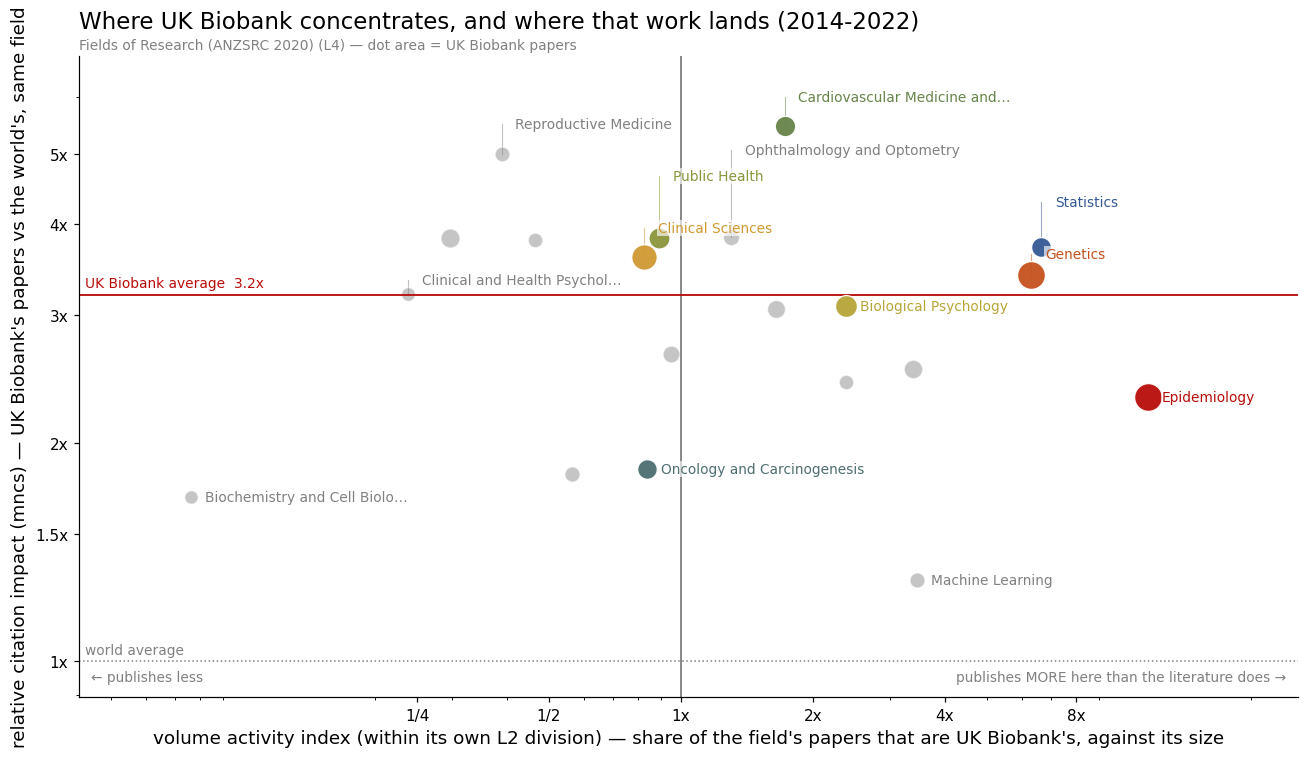

In [10]:
CHART5_M = 25          # categories to plot, UK Biobank's biggest first
_head = CITE_HEADLINE[2:]
_rci = f"rci_{_head}"

_big = (IMPACT.dropna(subset=[_rci, "activity_x"])
        .nlargest(CHART5_M, "ukbb_papers"))
_labels = {c: l for c, l in zip(TOP_CODES, TOP_LABELS)}
_ref = OVERALL[_head]

fig, ax = plt.subplots(figsize=STYLE["figsize"])
for code, r in _big.iterrows():
    top = code in _labels
    col = FIELD_COLORS[_labels[code]] if top else STYLE["edgecolor"]
    ax.scatter(r.activity_x, r[_rci], s=30 + 300 * np.sqrt(r.ukbb_papers / _big.ukbb_papers.max()),
               color=col, alpha=0.95 if top else 0.45, zorder=3 if top else 2,
               edgecolor="white", linewidth=0.8)

# Label the top-N (colour-matched to every other chart) plus whatever is extreme on
# either axis — those are the points a reader will ask about. The dementia family sits
# in one tight cluster, so labels are nudged apart in log space as in Chart 4.
_extreme = set(_big.nlargest(3, _rci).index) | set(_big.nsmallest(2, _rci).index) \
    | set(_big.nlargest(3, "activity_x").index) | set(_big.nsmallest(2, "activity_x").index)
_to_label = [(r[_rci], r.activity_x, code) for code, r in _big.iterrows()
             if code in _labels or code in _extreme]
_span = np.log10(_big[_rci].max() / _big[_rci].min())
_gap, _prev = 0.035 * (_span + 0.4), None
for value, xpos, code in sorted(_to_label):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    lab = label_of(code)
    col = FIELD_COLORS[lab] if code in _labels else STYLE["edgecolor"]
    # A nudged label must still point at its own dot, or the reader attaches it to a
    # neighbour; anything moved more than a hair gets a leader line.
    if abs(ly - np.log10(value)) > 0.008:
        ax.plot([xpos, xpos], [value, 10 ** ly], color=col, lw=0.7, alpha=0.5,
                zorder=1)
    ax.annotate(short(lab, 28), (xpos, 10 ** ly), color=col,
                fontsize=STYLE["annot_fs"], va="center",
                xytext=(9, 0), textcoords="offset points",
                bbox=dict(fc="white", ec="none", alpha=0.65, pad=0.6))

# World parity is drawn only when the data comes near it. Every disease UK Biobank
# works in is cited above world average, so forcing 1.0 onto the axis would spend half
# the panel on empty space; when it is off-scale the corner note says so instead.
SHOW_WORLD = _big[_rci].min() < 1.3
ax.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
ax.axhline(_ref, color=STYLE["colors"][0], lw=1.2)
if SHOW_WORLD:
    ax.axhline(1.0, color=STYLE["edgecolor"], lw=1, ls=":")
ax.set_xscale("log")
ax.set_yscale("log")
for axis, ticks in ((ax.xaxis, [0.25, 0.5, 1, 2, 4, 8]),
                    (ax.yaxis, [1, 1.5, 2, 3, 4, 5])):
    axis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v:g}x" if v >= 1 else f"1/{1 / v:g}"))
    axis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticks([0.25, 0.5, 1, 2, 4, 8])
ax.set_yticks([1, 1.5, 2, 3, 4, 5])
ax.set_xlim(_big.activity_x.min() / 1.8, _big.activity_x.max() * 2.2)
ax.set_ylim((1.0 if SHOW_WORLD else _big[_rci].min()) / 1.12,
            _big[_rci].max() * 1.25)

ax.annotate(f"UK Biobank average  {_ref:.1f}x", (ax.get_xlim()[0], _ref),
            color=STYLE["colors"][0], fontsize=STYLE["annot_fs"], va="bottom",
            xytext=(4, 3), textcoords="offset points")
if SHOW_WORLD:
    ax.annotate("world average", (ax.get_xlim()[0], 1.0), color=STYLE["edgecolor"],
                fontsize=STYLE["annot_fs"], va="bottom", xytext=(4, 3),
                textcoords="offset points")
else:
    ax.annotate(f"world average (1x) is below this axis — every {UNIT} shown is "
                f"cited above it", (0.01, 0.08), xycoords="axes fraction", ha="left",
                fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
# Name the halves rather than all four quadrants: with the reference line at UK
# Biobank's own average, "left" and "right" of it is the whole message.
ax.annotate("publishes MORE here than the literature does →", (0.99, 0.02),
            xycoords="axes fraction", ha="right", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
ax.annotate("← publishes less", (0.01, 0.02), xycoords="axes fraction",
            ha="left", va="bottom", fontsize=STYLE["annot_fs"],
            color=STYLE["edgecolor"])

ax.set_xlabel(f"volume activity index ({ACTIVITY_LABEL}) — share of the {UNIT}'s "
              f"papers that are UK Biobank's, against its size")
ax.set_ylabel(f"relative citation impact ({_head}) — UK Biobank's papers vs the "
              f"world's, same {UNIT}")
ax.set_title(f"Where UK Biobank concentrates, and where that work lands "
             f"({CITE_WIN[0]}-{CITE_WIN[1]})", loc="left", fontsize=STYLE["title_fs"],
             pad=18)
# Subtitle as an axes annotation, not a suptitle: a suptitle on a single-panel figure
# collides with the y-label once the ticks are this wide.
ax.annotate(f"{SYSTEM} ({LEVEL}{VIEW_NOTE}) — dot area = UK Biobank papers",
            (0, 1.005), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
flag_denominator(ax)
fig.tight_layout()
savefig(fig, f"05_impact_map_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_head}")
plt.show()


### 5.3 Chart 6 — Do the measures agree, and is the impact holding up?

* **Left — agreement.** The same fields under every weight that carries a ratio
  (`RCI_WEIGHTS`). Citation analysis lives or dies on whether a result survives the choice of
  measure: `mncs` divides out the field-year average but is a mean of ratios and so follows
  the biggest hits, while a top-decile rate ignores how big those hits are entirely. Where the
  markers sit together the result is **robust**; where they spread, the ranking is an
  **artefact of the measure** and should be reported as such. The dashed line of each colour
  is UK Biobank's *own* average on that measure — the reference a field should be judged
  against.
* **The spread statistic excludes `n_top50f`.** An above-median rate cannot exceed **2×** by
  construction (the world's rate is 50%), where a decile rate can reach 10× and `mncs` has no
  ceiling at all. Including it would put a floor under every field's "disagreement" that is
  arithmetic rather than evidence. It is still drawn — it just does not vote on whether the
  measures agree.
* **Right — over time.** The headline measure year by year. Impact ratios are noisier than
  volume shares (a field-year needs enough UK Biobank papers to have a mean at all), so thin
  cells are dropped rather than drawn as spikes.

*Saves as* `06_citation_impact_…`


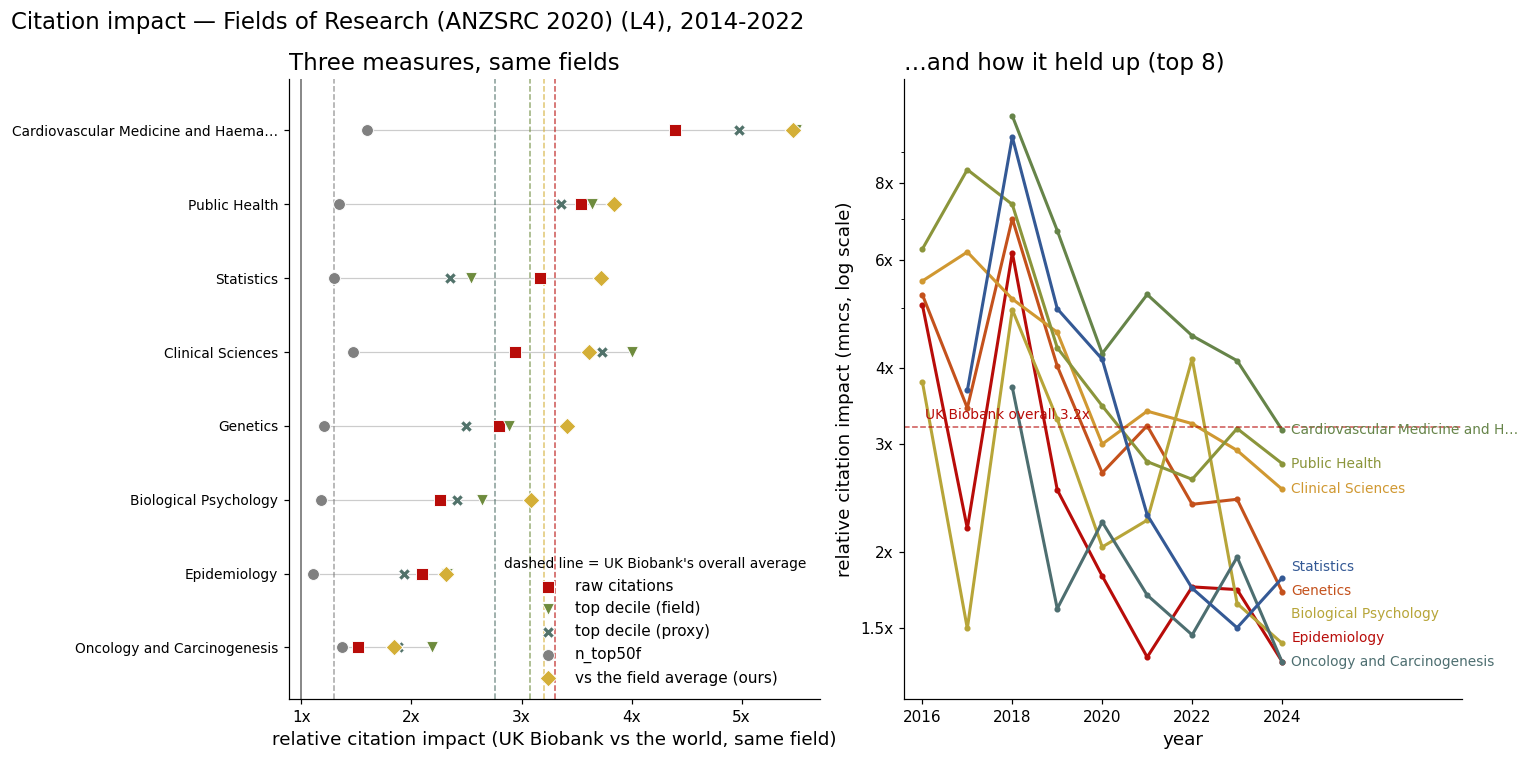

measure agreement over UK Biobank's top 8 fields (spread = max/min across the three weights):
  Cardiovascular Medicine and Haema…   raw  4.4x    top  5.5x    top  5.0x  n_top  1.6x     vs  5.5x   spread 3.45x
  Public Health                        raw  3.5x    top  3.6x    top  3.4x  n_top  1.3x     vs  3.8x   spread 2.85x
  Statistics                           raw  3.2x    top  2.5x    top  2.3x  n_top  1.3x     vs  3.7x   spread 2.87x
  Clinical Sciences                    raw  2.9x    top  4.0x    top  3.7x  n_top  1.5x     vs  3.6x   spread 2.72x
  Genetics                             raw  2.8x    top  2.9x    top  2.5x  n_top  1.2x     vs  3.4x   spread 2.83x
  Biological Psychology                raw  2.3x    top  2.6x    top  2.4x  n_top  1.2x     vs  3.1x   spread 2.62x
  Epidemiology                         raw  2.1x    top  2.3x    top  1.9x  n_top  1.1x     vs  2.3x   spread 2.10x
  Oncology and Carcinogenesis          raw  1.5x    top  2.2x    top  1.9x  n_top  1.4x     vs

In [11]:
CHART6_MIN_DOCS = CITE_MIN_DOCS_YEAR    # set in the parameter block

_head = CITE_HEADLINE[2:]
_order = (IMPACT.loc[[c for c in TOP_CODES if pd.notna(IMPACT.loc[c, f"rci_{_head}"])]]
          .sort_values(f"rci_{_head}"))
# Colour follows the MEASURE here, not the category, and it has to stay put whichever
# measures a given run happens to have — so the palette is assigned over the full known
# list and then filtered, rather than over whatever turned up today.
_W_ORDER = ["n_cit", "n_fcr", "n_mncs", "n_top10", "n_top10f", "n_top50f", "n_recent"]
_W_PAL = dict(zip(_W_ORDER, extended_palette(len(_W_ORDER))))
W_COLORS = {w: _W_PAL.get(w, STYLE["edgecolor"]) for w in RCI_WEIGHTS}
W_MARKERS = {"n_cit": "s", "n_fcr": "o", "n_mncs": "D", "n_top10": "^",
             "n_top10f": "v", "n_top50f": "X", "n_recent": "P"}
W_NAMES = {"n_cit": "raw citations", "n_fcr": "field-normalised (FCR)",
           "n_mncs": "vs the field average (ours)", "n_top10": "top decile (corpus)",
           "n_top10f": "top decile (field)", "n_top50f": "above the field median",
           "n_recent": "recent citations"}

# The measures that vote on whether the ranking is robust. n_top50f is drawn but left out
# of the spread: its ceiling is 2x by construction (the world is at 50% by definition), so
# it would widen every row's max/min for an arithmetic reason rather than a substantive one.
SPREAD_W = [w for w in RCI_WEIGHTS if w != "n_top50f"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"],
                               gridspec_kw={"width_ratios": [1, 1.05]})

# ---- left: every ratio-carrying measure, side by side -----------------------------
ypos = np.arange(len(_order))
for wt in RCI_WEIGHTS:
    vals = _order[f"rci_{wt[2:]}"]
    axL.scatter(vals, ypos, s=60, color=W_COLORS[wt], marker=W_MARKERS.get(wt, "o"),
                label=W_NAMES.get(wt, wt), zorder=3, edgecolor="white", linewidth=0.6)
    axL.axvline(OVERALL[wt[2:]], color=W_COLORS[wt], lw=1, ls="--", alpha=0.7)
# A hairline joining the measures makes the spread readable as one object per row.
for y, (_, r) in zip(ypos, _order.iterrows()):
    vals = [r[f"rci_{w[2:]}"] for w in RCI_WEIGHTS]
    axL.plot([min(vals), max(vals)], [y, y], color=STYLE["edgecolor"], lw=0.8,
             alpha=0.4, zorder=1)
axL.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
axL.set_yticks(ypos)
axL.set_yticklabels([short(label_of(c), 34) for c in _order.index],
                    fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.7, len(_order) - 0.3)
axL.set_xlabel("relative citation impact (UK Biobank vs the world, same "
               f"{UNIT})")
axL.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
axL.set_title(f"{len(RCI_WEIGHTS)} measures, same {UNIT}s", loc="left",
              fontsize=STYLE["title_fs"])
axL.legend(loc="lower right", frameon=False, fontsize=STYLE["legend_fs"],
           title="dashed line = UK Biobank's overall average",
           title_fontsize=STYLE["annot_fs"])

# ---- right: the headline measure, year by year -----------------------------------
rci_ts = (rci_timeseries(CITE_HEADLINE, CHART6_MIN_DOCS)
          .reindex(columns=TOP_CODES).set_axis(TOP_LABELS, axis=1))

ends = []
for lab in TOP_LABELS:
    s = rci_ts[lab].dropna()
    if not len(s):
        continue
    axR.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))
# As in Chart 5: world parity earns a line only when the data comes near it.
_dmin, _dmax = np.nanmin(rci_ts.values), np.nanmax(rci_ts.values)
if _dmin < 1.3:
    axR.axhline(1.0, color=STYLE["edgecolor"], lw=1.2)
axR.axhline(OVERALL[_head], color=STYLE["colors"][0], lw=1, ls="--", alpha=0.7)
axR.annotate(f"UK Biobank overall {OVERALL[_head]:.1f}x",
             (rci_ts.dropna(how="all").index.min(), OVERALL[_head]),
             color=STYLE["colors"][0], fontsize=STYLE["annot_fs"], va="bottom",
             xytext=(2, 3), textcoords="offset points")

_lo = min(v for v, _, _ in ends) if ends else 1.0
_hi = max(v for v, _, _ in ends) if ends else 3.0
_gap, _prev = 0.05 * (np.log10(_hi / _lo) + 0.4), None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (xend, 10 ** ly), color=FIELD_COLORS[lab],
                 fontsize=STYLE["annot_fs"], va="center",
                 xytext=(6, 0), textcoords="offset points")

axR.set_yscale("log")
# Ticks span the whole series, not just where the lines end — the early years are the
# highest points on this panel and were going unlabelled.
_ticks = [t for t in (0.5, 1, 1.5, 2, 3, 4, 6, 8, 12) if _dmin / 1.2 <= t <= _dmax * 1.2]
axR.set_yticks(_ticks)
axR.set_ylim((1.0 if _dmin < 1.3 else _dmin) / 1.15, _dmax * 1.15)
axR.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
_yrs = rci_ts.dropna(how="all").index
axR.set_xlim(int(_yrs.min()) - 0.4, int(_yrs.max()) + 4)
axR.set_xticks(year_ticks(_yrs.min(), _yrs.max(), 2))
axR.set_xlabel("year")
axR.set_ylabel(f"relative citation impact ({_head}, log scale)")
axR.set_title(f"…and how it held up (top {TOP_N})", loc="left",
              fontsize=STYLE["title_fs"])

fig.suptitle(f"Citation impact — {SYSTEM} ({LEVEL}{VIEW_NOTE}), "
             f"{CITE_WIN[0]}-{CITE_WIN[1]}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"06_citation_impact_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_head}")
plt.show()

# Abbreviations for the printed table: taken from a map, not by truncating W_NAMES, which
# gave two different weights the same five characters ("top d…" twice) and printed the raw
# column name for anything the map had missed.
_W_ABBR = {"n_cit": "cit", "n_fcr": "fcr", "n_mncs": "mncs", "n_top10": "top10",
           "n_top10f": "top10f", "n_top50f": "top50f", "n_recent": "recent"}
print(f"measure agreement over UK Biobank's top {TOP_N} {UNIT}s "
      f"(spread = max/min over {', '.join(_W_ABBR[w] for w in SPREAD_W)}; "
      f"top50f is shown but excluded — its ceiling is 2x by construction):")
for code in _order.index[::-1]:
    vals = {w: IMPACT.loc[code, f"rci_{w[2:]}"] for w in RCI_WEIGHTS}
    spread = [vals[w] for w in SPREAD_W]
    lab = label_of(code)
    print(f"  {short(lab, 34):34s} " + "  ".join(
        f"{_W_ABBR.get(w, w):>6s} {v:4.1f}x" for w, v in vals.items())
        + f"   spread {max(spread) / min(spread):.2f}x")


### 5.4 Chart 7 — UK Biobank's share of the world's citations over time

Chart 2 asked what share of the world's **papers** in a field are UK Biobank's. This asks
what share of the world's **citations** in that field are — which is the number a funder
actually wants: a resource can be 1% of the papers in a field and 3% of its citations, and
that gap is the whole argument for the resource.

The measure is set once, in §2, by `CITE_SHARE_METRIC`:

| value | share of the field's… |
|---|---|
| `n_papers` | papers — the volume baseline the citation shares are read against |
| `n_cit` | raw citations |
| `n_top10f` | **top-decile papers**, measured per field (see Chart 8) — the current setting |
| `n_top50f` | papers above the field's median |
| `n_fcr` / `n_top10` | the VM pathway's equivalents |

A share is the one place `n_cit` is safe: numerator and denominator are the same set of
papers in the same field-years, so the publication-year composition that rules out
`rci_cit` (§5) cancels here.

**Shares use the absolute columns, not the fractional ones.** "UK Biobank's share of
Epidemiology's citations" is a statement about Epidemiology, so a paper tagged both
Epidemiology and Genetics belongs whole to each. (The activity index and every impact ratio
use the fractional columns instead, because those compare *across* fields and a paper must not
be counted twice there.)

The requested metric may not exist in these partials — a run whose counts were built without
the `deciles` step has no per-field top-decile column, for instance. The cell then falls back
to the volume share, which every pathway can answer, and says so.

**The chart is labelled from the years it actually drew**, not from `CITE_WIN`. The two are
not the same: `CITE_WIN` is the *intersection* over every weight, while this chart follows one
measure and can reach a year the intersection does not.

*Saves as* `07_citation_share_…`

> **Three top-decile percentages live in this notebook, and they are not the same number.**
> All three share one numerator — UK Biobank's top-decile papers in the field — and differ
> only in what they are divided by:
>
> | | divided by | reads as | Epidemiology 2022 |
> |---|---|---|---|
> | **Chart 7**, Chart 8's upper line | the **field's** top-decile papers | "how much of this field's best work is UK Biobank's" | 7.9% |
> | **Chart 9's band height** | **all** the field's papers | "per 100 papers in the field, how many are UK Biobank's *and* top-decile" | 0.79% |
> | **Chart 9's in-panel %**, Chart 8's multiplier | **UK Biobank's own** papers in the field | "how much of UK Biobank's work here is top-decile" (10% = ordinary) | 20.3% |
>
> They are linked by `chart 7 = (in-panel %) × (footprint share) ÷ (pool size)`, and the
> pool is ~10% of a field by construction, so the band is Chart 7's value divided by ten.
> Two of them being close in a given year is a coincidence, not a cross-check: in
> Epidemiology 2018 the same three read 3.65%, 0.36% and 39.6%.


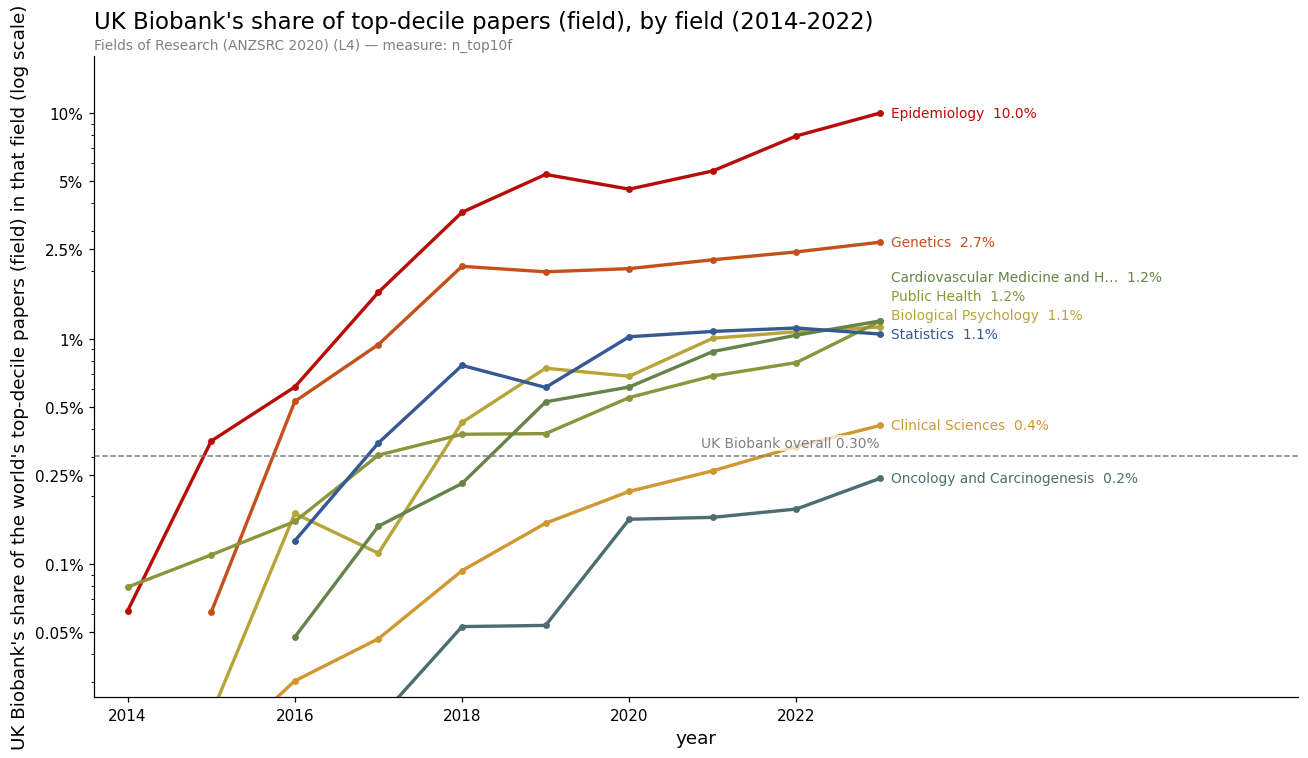

UK Biobank's share of the world's top-decile papers (field), 2022 (and how it moved since 2014):

  Epidemiology                              10.04%   ( 0.06% in 2014, up 9.98pp)
  Genetics                                   2.68%   ( 0.06% in 2015, up 2.62pp)
  Cardiovascular Medicine and Haematology    1.20%   ( 0.05% in 2016, up 1.15pp)
  Public Health                              1.20%   ( 0.08% in 2014, up 1.12pp)
  Biological Psychology                      1.13%   ( 0.02% in 2015, up 1.11pp)
  Statistics                                 1.05%   ( 0.13% in 2016, up 0.92pp)
  Clinical Sciences                          0.41%   ( 0.01% in 2014, up 0.40pp)
  Oncology and Carcinogenesis                0.24%   ( 0.01% in 2015, up 0.23pp)


In [ ]:
_m = CITE_SHARE_METRIC
if _m not in MEASURES:
    print(f"CITE_SHARE_METRIC={_m} is not in these partials "
          f"(have: {', '.join(m for m in MEASURES if not m.endswith('_docs'))});"
          f"\nfalling back to n_papers — the volume share.\n")
    _m = "n_papers"
_mname = {"n_papers": "papers", "n_cit": "citations", "n_mncs": "field-relative citations",
          "n_fcr": "field-normalised citation weight",
          "n_top10": "top-decile papers",
          "n_top10f": "top-decile papers (field)",
          "n_top50f": "papers above the field median"}[_m]
_cshare = share_timeseries(_m)
if _m in CITE_YEARS:                      # citation metrics stop where the data does
    _cshare = _cshare.loc[_cshare.index.isin(CITE_YEARS[_m])]
_cshare = _cshare.rename(columns=dict(zip(TOP_CODES, TOP_LABELS)))
# A share of exactly zero has no place on a log axis — matplotlib draws it as a line
# dropping off the bottom of the panel, which reads as a crash rather than as "UK
# Biobank had no papers in this field that year". Blank them instead.
_cshare = _cshare.where(_cshare > 0)

fig, ax = plt.subplots(figsize=STYLE["figsize"])
ends = []
for lab in TOP_LABELS:
    s = _cshare[lab].dropna()
    if not len(s):
        continue
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2.2, marker="o", ms=3.5)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))

# Direct labels carrying the final value, so the chart can be read without the axis.
_lo = min(v for v, _, _ in ends) if ends else 0.1
_hi = max(v for v, _, _ in ends) if ends else 1.0
_gap, _prev = 0.042 * (np.log10(_hi / max(_lo, 1e-6)) + 0.4), None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    ax.annotate(f"{short(lab, 30)}  {value:.1f}%", (xend, 10 ** ly),
                color=FIELD_COLORS[lab], fontsize=STYLE["annot_fs"], va="center",
                xytext=(7, 0), textcoords="offset points")

# UK Biobank's overall share of this measure — the line a field has to beat to be one
# of its stronger showings rather than simply a big field.
_u_all = ukbb[ukbb.year.between(*CITE_WIN)][_m].sum()
_w_all = whole[whole.year.between(*CITE_WIN)][_m].sum()
_overall_share = 100 * _u_all / _w_all
ax.axhline(_overall_share, color=STYLE["edgecolor"], lw=1, ls="--")
ax.annotate(f"UK Biobank overall {_overall_share:.2f}%",
            (int(_cshare.dropna(how="all").index.max()), _overall_share),
            color=STYLE["edgecolor"], fontsize=STYLE["annot_fs"], va="bottom",
            ha="right", xytext=(0, 4), textcoords="offset points",
            bbox=dict(fc="white", ec="none", alpha=0.7, pad=0.6))

ax.set_yscale("log")            # shares span two orders of magnitude across fields
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
# The early years are a rounding error against today's shares — a field UK Biobank
# entered in 2015 starts at 0.01% — and letting them set the floor squashes the decade
# that matters into the top inch. The axis starts two decades below the LATEST values
# instead, so the lines enter from the bottom rather than dictating the scale.
_floor = max(_hi / 300, float(np.nanmin(_cshare.values)))
_ticks = [t for t in (0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1, 2.5, 5, 10, 25)
          if _floor / 1.2 <= t <= _hi * 1.6]
ax.set_yticks(_ticks)
ax.set_ylim(_floor / 1.3, _hi * 1.8)
# The span this chart DREW, which is not CITE_WIN: CITE_WIN is the intersection over every
# weight, and _m follows its own measure's years (CITE_YEARS[_m]). Labelling from CITE_WIN
# put "2022" on a series whose last point is 2023.
_yrs = _cshare.dropna(how="all").index
_drawn_lo, _drawn_hi = int(_yrs.min()), int(_yrs.max())
ax.set_xlim(_drawn_lo - 0.4, _drawn_hi + 6)
# Ticks anchored on the last drawn year too: stepping by 2 from 2014 stops at 2022, which
# left the 2023 endpoint sitting past an unlabelled tick and reading as 2022.
ax.set_xticks(year_ticks(_drawn_lo, _drawn_hi, 2))
ax.set_xlabel("year")
ax.set_ylabel(f"UK Biobank's share of the world's {_mname} in that {UNIT} (log scale)")
ax.set_title(f"UK Biobank's share of {_mname}, by {UNIT} ({_drawn_lo}-{_drawn_hi})",
             loc="left", fontsize=STYLE["title_fs"], pad=18)
ax.annotate(f"{SYSTEM} ({LEVEL}{VIEW_NOTE}) — measure: {_m}", (0, 1.005),
            xycoords="axes fraction", ha="left", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
flag_denominator(ax)
fig.tight_layout()
savefig(fig, f"07_citation_share_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_m}")
plt.show()

# Each field's own first and last year, because they differ: a measured cut-off exists
# only where it was measured, so Cardiovascular starts two years after Epidemiology.
print(f"UK Biobank's share of the world's {_mname}, {_drawn_hi} "
      f"(and how it moved since each {UNIT}'s first measured year):\n")
for value, last_year, lab in sorted(ends, reverse=True):
    s = _cshare[lab].dropna()
    first = float(s.iloc[0])
    arrow = "up" if value > first else "down"
    print(f"  {short(lab, 40):40s} {value:6.2f}% in {int(last_year)}   "
          f"({first:5.2f}% in {int(s.index[0])}, {arrow} {abs(value - first):.2f}pp)")


### 5.5 Chart 8 — The top-decile premium

The most direct statement this data can make. Two lines per field:

* **share of all papers** — what fraction of the world's work in this field is UK Biobank's:
  its *footprint*
* **share of top-decile papers** — what fraction of the field's **most-cited tenth** is UK
  Biobank's: its footprint among the work that *landed*

If UK Biobank were an average producer in a field the two lines would sit on top of each
other: holding 2% of the papers would mean holding 2% of the best ones. The shaded gap between
them is therefore **the premium, in units the reader already understands**, with no index or
ratio in between. The multiplier printed in each panel is the two divided — the same quantity
Chart 6 calls `rci_top10f`, shown here as the thing it is made of.

`TOP10_COL` is whichever top-decile measure this run carries, and the two are defined against
different reference populations:

* **`n_top10f`** (this run) — the most-cited tenth **of the field itself**, per (year, field),
  against a cut-off found by counting (`dimensions_api.py deciles`, or the VM job's
  per-category thresholds). This is PP(top 10%) as the bibliometric literature defines it.
* **`n_top10`** (VM fallback) — the most-cited tenth of the **whole corpus** for that (year,
  type). A citation-heavy field then holds more than a tenth of its papers in it, so that
  version may only be compared *within* a field, never across.

*Saves as* `08_top_decile_premium_…`


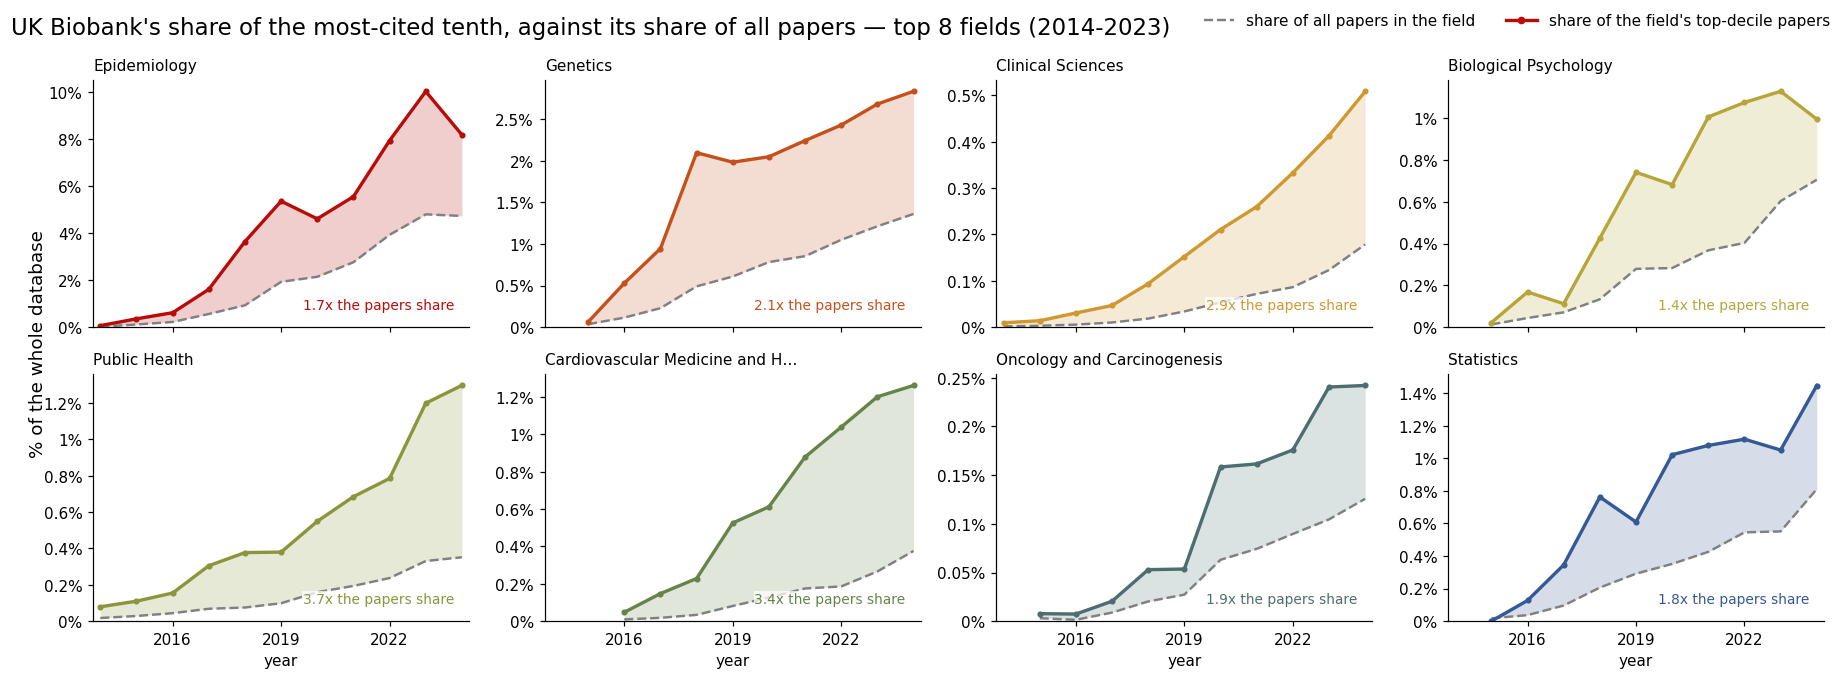

in 2023, UK Biobank held:

  Epidemiology                        10.04% of the top-decile papers vs  4.80% of all papers   = 2.1x
  Genetics                             2.68% of the top-decile papers vs  1.21% of all papers   = 2.2x
  Clinical Sciences                    0.41% of the top-decile papers vs  0.12% of all papers   = 3.4x
  Biological Psychology                1.13% of the top-decile papers vs  0.60% of all papers   = 1.9x
  Public Health                        1.20% of the top-decile papers vs  0.33% of all papers   = 3.6x
  Cardiovascular Medicine and Haema…   1.20% of the top-decile papers vs  0.27% of all papers   = 4.5x
  Oncology and Carcinogenesis          0.24% of the top-decile papers vs  0.10% of all papers   = 2.3x
  Statistics                           1.05% of the top-decile papers vs  0.55% of all papers   = 1.9x


In [13]:
if TOP10_COL is None:
    print("no top-decile column — VM: --weights top10,top10f; API: the `deciles` mode")
else:
    _paper = share_timeseries("n_papers")
    _best = share_timeseries(TOP10_COL)
    # Measured field/year thresholds are available through the latest indexed year;
    # do not apply the raw-citation lag window to this already-thresholded metric.
    _yrs = sorted(set(_best.index) & set(_paper.index))
    _paper, _best = _paper.loc[_paper.index.isin(_yrs)], _best.loc[_best.index.isin(_yrs)]

    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.1 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        p, b = _paper[code].dropna(), _best[code].dropna()
        idx = p.index.intersection(b.index)
        p, b = p.reindex(idx), b.reindex(idx)
        # Shade the premium, and shade a shortfall in the opposite direction — a field
        # where UK Biobank holds fewer of the best papers than of the papers is a real
        # possibility and must not be drawn as if it were a premium.
        ax.fill_between(idx, p, b, where=(b >= p), color=col, alpha=0.20,
                        interpolate=True, lw=0)
        ax.fill_between(idx, p, b, where=(b < p), color=STYLE["edgecolor"], alpha=0.25,
                        interpolate=True, lw=0)
        ax.plot(idx, p, color=STYLE["edgecolor"], lw=1.6, ls="--")
        ax.plot(idx, b, color=col, lw=2.2, marker="o", ms=3)
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        if len(b) and len(p) and p.iloc[-1] > 0:
            ax.annotate(f"{b.iloc[-1] / p.iloc[-1]:.1f}x the papers share",
                        xy=(0.96, 0.06), xycoords="axes fraction", ha="right",
                        va="bottom", fontsize=STYLE["annot_fs"], color=col,
                        bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.6))
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(_yrs[0], _yrs[-1], 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([], [], color=STYLE["edgecolor"], lw=1.6, ls="--",
               label="share of all papers in the field"),
        Line2D([], [], color=STYLE["colors"][0], lw=2.2, marker="o", ms=4,
               label="share of the field's top-decile papers")],
        loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
    fig.suptitle(f"UK Biobank's share of the most-cited tenth, against its share of all "
                 f"papers — top {TOP_N} {UNIT}s ({CITE_YEARS[TOP10_COL][0]}-"
                 f"{CITE_YEARS[TOP10_COL][-1]})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left")
    fig.supylabel("% of the whole database", fontsize=STYLE["label_fs"])
    flag_denominator(fig)
    fig.tight_layout()
    savefig(fig, f"08_top_decile_premium_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last = CITE_YEARS[TOP10_COL][-1]
    print(f"in {_last}, UK Biobank held:\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        p, b = _paper[code].get(_last, np.nan), _best[code].get(_last, np.nan)
        if not (np.isfinite(p) and np.isfinite(b) and p > 0):
            continue
        print(f"  {short(lab, 34):34s} {b:6.2f}% of the top-decile papers vs "
              f"{p:5.2f}% of all papers   = {b / p:.1f}x")


## 6. Quality bands — the citation cut-offs behind the percentiles

§5 works in ratios. This part puts the same claim back into counts a reader can check a single
paper against: what "top decile" and "above the median" were **worth in citations** in each
year, how much of UK Biobank's footprint in a field clears each bar, and how large the field's
top-cited pool is in the first place.

| | question |
|---|---|
| §6.1 | what were the cut-offs, per (year, field)? |
| Chart 9 | how much of UK Biobank's slice of a field is in the world's most-cited tenth? |
| Chart 9a | …and how much of it is at least above the field's median? |
| Chart 9b | were the bands moving, or were the cut-offs? |
| Chart 10 | how big is the field's top-decile pool, and how much of it is UK Biobank's? |

All of §6 needs cut-off columns that only some pathways carry; each cell says what is missing
and skips itself rather than drawing something it cannot support.


### 6.1 The cut-offs behind the quality bands

Charts 9, 9a and 10 all split UK Biobank's papers by where they land in their **own field's**
citation distribution. "Top decile" and "above the median" are percentile language; this cell
puts both back into a unit a reader can check a single paper against, and hands the charts a
per-panel annotation built from it.

* **`thr10`** — the top-decile cut-off for that (year, field): the lowest citation count
  whose at-or-above tail is still inside the field's most-cited tenth. Binary-searched
  cell by cell against the live index (`percentiles --percentiles 10`), so it exists only
  where it was measured — 2015 onwards for most of UK Biobank's fields, 2017 for the three
  that entered its top eight late.

* **`median`** — the field-year median, measured **the same way** (`--percentiles 50`) and
  in the same pass, so it is an **integer** cut-off with the field's own count above it.
  This is the cut-off the `n_top50f` band uses, and because that count is measured, the
  whole-database side of the band is counted rather than imputed at half the field.

  Both cut-offs come back with the share they actually achieved, which is the honest
  reading of how well a cell supports a percentile at all. Over the 254 measured cells:
  the decile lands at **8.55-10.00%** (median 9.81%) — tight, because a tail has few ties
  — while the median lands at **35.35-50.00%** (median **47.95%**), and **36 cells** fall
  more than five points short. That is not error: citations are small integers with
  enormous ties, so in a recent year the cut sits at ">= 1 citation" and more than half
  the field is uncited. The count above the cut is still exact; what is approximate is
  calling it the 50th percentile.

  *(Before this was measured, the notebook read `citations_median` off the facet — an
  interpolated percentile that came back fractional (0.1, 0.88, 2.02) in 1,873 of 2,052
  cells, silently cut at `ceil()`, and forced the background arm to assume exactly half
  the field. Cells the percentile pass never reached still fall back to it, and say so.)*

* **`mean`** — the field-year mean, **for scale only**. Citation distributions are skewed hard
  enough that the mean sits near the 70th percentile, not in the middle: in 2020 Epidemiology
  the mean is 27.8 and the median is 6.0.

All three fall steeply with publication year because citations accrue — 2016's tenth-best
Epidemiology paper needed 59 citations, 2024's needs 16. **That is the clock, not a decline in
standards**, and it is exactly why the cut is taken per year.


In [14]:
CUTS = None
if SOURCE == "api":
    try:
        # field_thresholds carries one row per (year, field, PERCENTILE): the top decile
        # and the median are two measurements of the same cell, so each is picked out by
        # its own percentile rather than merged blind.
        _thr = pd.read_csv(COUNTS_DIR / f"field_thresholds.{COL_TYPE}.csv",
                           dtype={"code": str})
        if "percentile" not in _thr.columns:
            _thr["percentile"] = 10.0      # a file from before the percentiles mode
        _thr = _thr[_thr.level == LEVEL]
        _med = pd.read_parquet(COUNTS_DIR / f"api_whole.{COL_TYPE}.parquet",
                               columns=["year", "level", "code", "mean_cit",
                                        "api_citations_median"])
        _p10 = (_thr.loc[_thr.percentile == 10, ["year", "code", "threshold"]]
                .rename(columns={"threshold": "thr10"}))
        _cols50 = ["year", "code", "threshold"] + (
            ["achieved_pct"] if "achieved_pct" in _thr.columns else [])
        _p50 = (_thr.loc[_thr.percentile == 50, _cols50]
                .rename(columns={"threshold": "med_meas", "achieved_pct": "med_pct"}))
        if "med_pct" not in _p50.columns:
            _p50["med_pct"] = np.nan
        CUTS = (_med[_med.level == LEVEL]
                .merge(_p10, on=["year", "code"], how="left")
                .merge(_p50, on=["year", "code"], how="left")
                .astype({"year": int}))
        # The MEASURED median wherever the percentile pass reached the cell; only
        # otherwise the facet's interpolated citations_median, which is fractional, cuts
        # at ceil() and has no count of the field behind it (§6.1).
        CUTS["median_measured"] = CUTS.med_meas.notna()
        CUTS["median"] = CUTS.med_meas.fillna(CUTS.api_citations_median)
        CUTS = CUTS.set_index(["year", "code"])[["thr10", "median", "mean_cit",
                                                 "med_pct", "median_measured"]]
        _n10, _n50 = int(CUTS.thr10.notna().sum()), int(CUTS.median_measured.sum())
        print(f"cut-offs: top decile measured in {_n10} cell(s), median in {_n50}"
              + ("" if _n50 else " — falling back to the facet's INTERPOLATED median")
              + "\n")
    except (FileNotFoundError, KeyError) as exc:
        print(f"no cut-off tables in {COUNTS_DIR} ({exc}) — the charts draw without them")

def _cit(v):
    """A citation cut-off as a reader would say it: 59, 6, 0.4."""
    return "–" if v != v else (f"{v:.0f}" if v >= 1 else f"{v:.1f}")


def _cites(v):
    """The same, with its unit: "16 cites", "1 cite", "0.4 cites"."""
    return "–" if v != v else f"{_cit(v)} cite" + ("" if v == 1 else "s")

def contiguous_tail(index):
    """The longest run of CONSECUTIVE years ending at the last one.

    A cut-off exists only where it was measured, and the cells that were measured are
    the ones UK Biobank had papers in — so a field can have 2015 measured, 2016 and
    2017 not, and 2018 onwards measured again. Plotting that index as-is draws a
    straight line across the hole, which reads as a smooth trend through years nobody
    looked at. Dropping the isolated head is the honest reading: the panel starts where
    the uninterrupted record starts.
    """
    years = [int(y) for y in index]
    if len(years) < 2:
        return index
    keep = [years[-1]]
    for y in reversed(years[:-1]):
        if keep[0] - y != 1:
            break
        keep.insert(0, y)
    return index[[years.index(y) for y in keep]]


def cut_note(code, year):
    """One line naming what the bands mean in citations, for a single year.

    The cut-offs move every year — 2016's decile in Epidemiology is 59 citations and
    2024's is 16 — but a panel does not need the whole series to stay readable: what a
    reader wants is what "top decile" is worth at the sharp end of the chart, so only the
    final year is quoted here and the printed table below carries the rest.
    """
    if CUTS is None:
        return ""
    r = CUTS.reindex([(int(year), code)]).iloc[0]
    if r["median"] != r["median"]:
        return ""
    ten = "" if r.thr10 != r.thr10 else f"top 10% ≥ {_cites(r.thr10)}   ·   "
    # A measured median cut says what share of the field it actually kept. Where that is
    # far off 50% the ties could not be split (most of the field is uncited), and the
    # band is "cited at all" rather than "above the median" — so the panel says so.
    got = r.get("med_pct", float("nan")) if hasattr(r, "get") else r["med_pct"]
    tail = ("" if (got != got or abs(got - 50) <= 5)
            else f" (= top {got:.0f}% of the {UNIT})")
    return f"{int(year)}:   {ten}median ≥ {_cites(r['median'])}{tail}"


if CUTS is not None:
    _show = [y for y in (2016, 2020, YEAR_MAX) if (y, TOP_CODES[0]) in CUTS.index]
    print(f"citation cut-offs per {UNIT} and year — what the bands are made of:\n")
    print(f"  {'':34s}" + "".join(f"{y:^24d}" for y in _show))
    print(f"  {'':34s}" + "".join(f"{'top10%   median   mean':^24s}" for _ in _show))
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        cells = ""
        for y in _show:
            r = CUTS.reindex([(y, code)]).iloc[0]
            cells += f"{_cit(r.thr10):>7s}{_cit(r['median']):>9s}{_cit(r.mean_cit):>8s}"
        print(f"  {short(lab, 32):34s}{cells}")
    print("\n(the cut-offs fall with year because citations accrue; a 2024 paper has had "
          "one year\n to collect them and a 2016 paper nine)")

citation cut-offs per field and year — what the bands are made of:

                                              2016                    2020                    2024          
                                     top10%   median   mean  top10%   median   mean  top10%   median   mean 
  Epidemiology                           59        5      29     54        6      28     16        2       7
  Genetics                               74       12      39     46        8      22     14        2       6
  Clinical Sciences                      48        4      20     35        4      17     11      0.9       4
  Biological Psychology                  72       11      30     45        7      19     14        2       5
  Public Health                          57        7      25     44        6      20     13        1       5
  Cardiovascular Medicine and Hae…       39        2      16     28        2      12      9      0.1       3
  Oncology and Carcinogenesis            62        6      28

### 6.2 Chart 9 — UK Biobank's footprint, split by quality

Chart 8 draws two shares and asks the reader to compare them. This draws **one** share — UK
Biobank's slice of the field, exactly the dashed line from Chart 8 — and colours the part of it
that landed in the world's most-cited tenth:

| | |
|---|---|
| **total height** | UK Biobank's papers as a % of all the field's papers |
| **coloured band** | those of them in the top decile, as a % of all the field's papers |
| **pale band** | the rest of UK Biobank's papers |

So the height is the **footprint** and the colour is the **quality inside it**, with no second
line to hold in your head. The dotted line inside each panel is the same band as it would be if
UK Biobank's papers were ordinary — **a tenth of its own output**, because a decile puts 10% of
the reference population above the cut by definition. **Colour reaching above that line is the
entire claim**; the ratio of the band to the dotted line is Chart 8's multiplier.

**How the top decile is defined — and against what.** `TOP10_COL` decides, and the two possible
answers have different reference populations:

* **`n_top10f` (this run, API `deciles` mode).** Per **(year, field)**. For each cell the cut-off
  is binary-searched against the live index — `times_cited >= X` counted, X halved in on — until
  the tail at or above it is just inside 10% of *that field's* papers that year. ~8 queries a
  cell; the achieved percentile lands at 8.5–10.0% (median 9.8%), because ties make an exact 10%
  unreachable and the cut is taken conservatively. Both arms are then scored against the same
  cut-off, so this is PP(top 10%) as the bibliometric literature defines it.
* **`n_top10` (VM fallback, the `citdist` / `thresholds` passes).** Per **(year, type)** over the
  whole corpus: `citdist` builds an exact histogram of `times_cited` (small integers, so no
  sampling), `thresholds` reads the lowest count whose tail stays inside the top 10%. For
  articles that is ≥49 citations in 2014, ≥17 in 2022, ≥10 in 2023.

The distinction matters for how far a reading may travel. The **field** decile is comparable
across fields, because every field puts 10% of its own papers above its own bar. The **global**
one is not: a heavily-cited field (oncology) holds more than a tenth of its papers in it and a
slow-citing field fewer, so under `n_top10` this chart may only be read down a column, never
across.

Cells whose cut-off was never measured are drawn as a **gap**, not as a zero — "we did not look"
and "none of its papers made it" must not look the same, which is what the `_docs` counters are
for.

*Saves as* `09_footprint_quality_…`

> **Three top-decile percentages live in this notebook, and they are not the same number.**
> All three share one numerator — UK Biobank's top-decile papers in the field — and differ
> only in what they are divided by:
>
> | | divided by | reads as | Epidemiology 2022 |
> |---|---|---|---|
> | **Chart 7**, Chart 8's upper line | the **field's** top-decile papers | "how much of this field's best work is UK Biobank's" | 7.9% |
> | **Chart 9's band height** | **all** the field's papers | "per 100 papers in the field, how many are UK Biobank's *and* top-decile" | 0.79% |
> | **Chart 9's in-panel %**, Chart 8's multiplier | **UK Biobank's own** papers in the field | "how much of UK Biobank's work here is top-decile" (10% = ordinary) | 20.3% |
>
> They are linked by `chart 7 = (in-panel %) × (footprint share) ÷ (pool size)`, and the
> pool is ~10% of a field by construction, so the band is Chart 7's value divided by ten.
> Two of them being close in a given year is a coincidence, not a cross-check: in
> Epidemiology 2018 the same three read 3.65%, 0.36% and 39.6%.


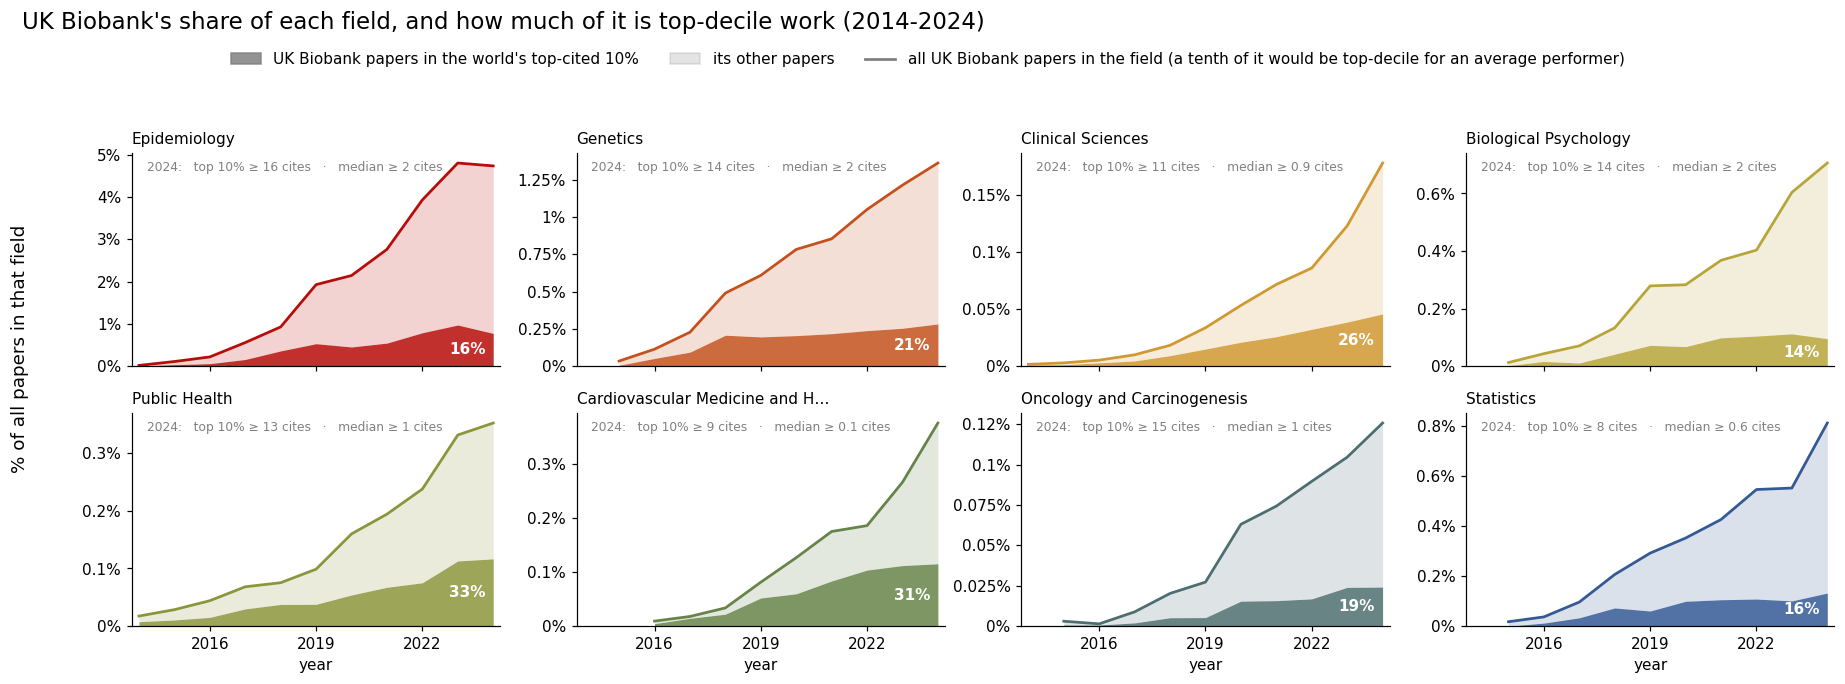

in 2024, of every 100 papers published in each field:

  Epidemiology                      4.73 were UK Biobank's, of which  0.78 were top-decile (16.4% of them, vs ~10% for an ordinary paper)
  Genetics                          1.36 were UK Biobank's, of which  0.28 were top-decile (20.8% of them, vs ~10% for an ordinary paper)
  Clinical Sciences                 0.18 were UK Biobank's, of which  0.05 were top-decile (25.7% of them, vs ~10% for an ordinary paper)
  Biological Psychology             0.71 were UK Biobank's, of which  0.10 were top-decile (13.6% of them, vs ~10% for an ordinary paper)
  Public Health                     0.35 were UK Biobank's, of which  0.12 were top-decile (33.1% of them, vs ~10% for an ordinary paper)
  Cardiovascular Medicine and Hae…  0.38 were UK Biobank's, of which  0.12 were top-decile (30.7% of them, vs ~10% for an ordinary paper)
  Oncology and Carcinogenesis       0.13 were UK Biobank's, of which  0.02 were top-decile (19.2% of them, vs ~10% fo

In [15]:
if TOP10_COL is None:
    print("no top-decile column — VM: --weights top10,top10f; API: the `deciles` mode")
else:
    _all = share_timeseries("n_papers")                              # the footprint
    _best = share_timeseries(TOP10_COL, denominator="n_papers")      # its top-decile part
    # A (year, field) whose decile cut-off was never measured comes back as a zero count
    # rather than as a gap, and zero would draw as "none of its papers made the decile" —
    # the opposite of "we did not look". The _docs counter says which it is.
    _best = _best.where(
        (ukbb[ukbb.code.isin(TOP_CODES)]
         .pivot_table(index="year", columns="code", values=f"{TOP10_COL}_docs",
                      aggfunc="sum").reindex(columns=TOP_CODES)
         .reindex_like(_best)) > 0)
    # Use all years present in the measured field/year threshold series, including 2024.
    _yrs = sorted(set(_best.index) & set(_all.index))
    _all = _all.loc[_all.index.isin(_yrs)]
    _best = _best.loc[_best.index.isin(_yrs)]
    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.1 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    _drawn = []          # the years each panel could actually draw, for the title
    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        a, b = _all[code].dropna(), _best[code].dropna()
        idx = a.index.intersection(b.index)
        idx = contiguous_tail(idx)
        a, b = a.reindex(idx), b.reindex(idx)
        if not len(idx):
            continue
        _drawn += [int(idx[0]), int(idx[-1])]
        ax.fill_between(idx, 0, b, color=col, alpha=0.85, lw=0)
        ax.fill_between(idx, b, a, color=col, alpha=0.18, lw=0)
        ax.plot(idx, a, color=col, lw=1.8)
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        # The headline number sits INSIDE the band it describes, in white — no leader
        # line, no legend lookup, and it cannot be mistaken for the pale band's share.
        if len(a) and a.iloc[-1] > 0 and b.iloc[-1] > 0:
            ax.annotate(f"{100 * b.iloc[-1] / a.iloc[-1]:.0f}%",
                        xy=(idx[-1], b.iloc[-1] / 2), xytext=(-5, 0),
                        textcoords="offset points", ha="right", va="center",
                        color="white", fontsize=STYLE["annot_fs"] + 1,
                        fontweight="bold")
        # What "top decile" is worth in citations, in the year the chart ends on. The
        # full series of cut-offs is in the table the cell above prints.
        ax.annotate(cut_note(code, idx[-1]), xy=(0.04, 0.96),
                    xycoords="axes fraction", ha="left", va="top",
                    fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"])
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(min(_drawn), max(_drawn), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    # The legend describes the ENCODING, not any one field, so its patches are neutral
    # grey — in red they would read as "red = top decile" when every panel has its own
    # colour. It sits on its own line under the title rather than beside it, which a
    # three-entry legend cannot share with a full-width heading.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    # The y-axis is a share of the FIELD and the number written inside the band is a share
    # of UK BIOBANK'S OWN papers — two denominators on one panel, and the reason chart 7's
    # "10% of the field's best work is ours" and this chart's "16% of ours is top-decile"
    # are different statements. The figure has to carry that, not just the notebook.
    fig.text(0.01, 0.905, f"numbers inside the bands are shares of UK Biobank's own "
             f"papers in that {UNIT} (10% = an ordinary paper); the axis is a share of "
             f"the whole {UNIT}", fontsize=STYLE["annot_fs"] - 1,
             color=STYLE["edgecolor"], ha="left", va="top")
    fig.legend(handles=[
        Patch(color=STYLE["edgecolor"], alpha=0.85,
              label="UK Biobank papers in the world's top-cited 10%"),
        Patch(color=STYLE["edgecolor"], alpha=0.22, label="its other papers"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8,
               label="all UK Biobank papers in the field (a tenth of it would be "
                     "top-decile for an average performer)")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
        fontsize=STYLE["legend_fs"])
    fig.suptitle(f"UK Biobank's share of each {UNIT}, and how much of it is top-decile "
                 f"work ({min(_drawn)}-{max(_drawn)})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"% of all papers in that {UNIT}", fontsize=STYLE["label_fs"], x=0.004)
    flag_denominator(fig)
    # tight_layout does not know about the suptitle, the legend line or the supylabel;
    # the rect leaves room for all three.
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    savefig(fig, f"09_footprint_quality_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last = max(_drawn)
    print(f"in {_last}, of every 100 papers published in each {UNIT}:\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        a, b = _all[code].get(_last, np.nan), _best[code].get(_last, np.nan)
        if not (np.isfinite(a) and np.isfinite(b) and a > 0):
            continue
        print(f"  {short(lab, 32):32s} {a:5.2f} were UK Biobank's, of which {b:5.2f} "
              f"were top-decile ({100 * b / a:4.1f}% of them, vs ~10% for an "
              f"ordinary paper)")

### 6.3 Chart 9a — The footprint cut twice: the best tenth and the better half

Chart 9 asks "how much of UK Biobank's slice of this field is world-class?" and answers with one
band. The top decile is a demanding bar, though, and a paper just under it is not an ordinary
paper — so this splits the same slice at **both** cut-offs:

| | |
|---|---|
| **total height** | UK Biobank's papers as a % of all the field's papers |
| **solid band** | those in the field's most-cited **tenth** |
| **pale band** | the rest of those above the field's **median** |
| **white** | the rest — below the median of their own field |

The two reference points would be arithmetic if the cuts were exact — an ordinary paper is in
its field's top decile **a tenth** of the time and above its field's median **half** the time —
so a solid band at 16% of the line reads as 1.6× an ordinary performance and a pale band at 55%
as 1.1×. **Use the measured share, not the round number, wherever the two differ.** The decile
cut achieves 8.6-10.0% and the round 10% is safe; the median cut achieves 35-50% (median 48%),
so in the years where it falls short, dividing by 50 understates the multiplier — a 58% band
against a cut that keeps 36% of the field is 1.6×, not 1.2×. §6.1 prints what each cell
achieved, and the panel annotation carries it wherever it is more than five points off.

White is deliberately empty: the solid line already draws the footprint, so an unfilled gap under
it reads as "the part of UK Biobank's output that is not above the median" without adding a
fourth colour.

**Both cut-offs are measured the same way** — binary-searched per (year, field) against
the live index by `percentiles --percentiles 10,50`, ~13 queries a cell for the pair,
which is why they start in 2015-2017 and not 2013. Neither is interpolated and neither
side of either band is imputed: the pass records `n_at_or_above`, the whole database's own
count above the cut, so UK Biobank's papers and the world's are counted against the same
integer bar.

What survives is not an error but a limit: **a percentile is often unreachable**. Half a
field's papers is a big enough set that the median cut is usually within a point or two of
50%, but in 2023-24, where most papers are uncited, the cut lands at ">= 1 citation" and
keeps as little as 35% of the field. The measured share is recorded per cell, so a panel
whose median band is really "cited at all" says so rather than quietly claiming half.

*Saves as* `09a_footprint_quality_median_…`


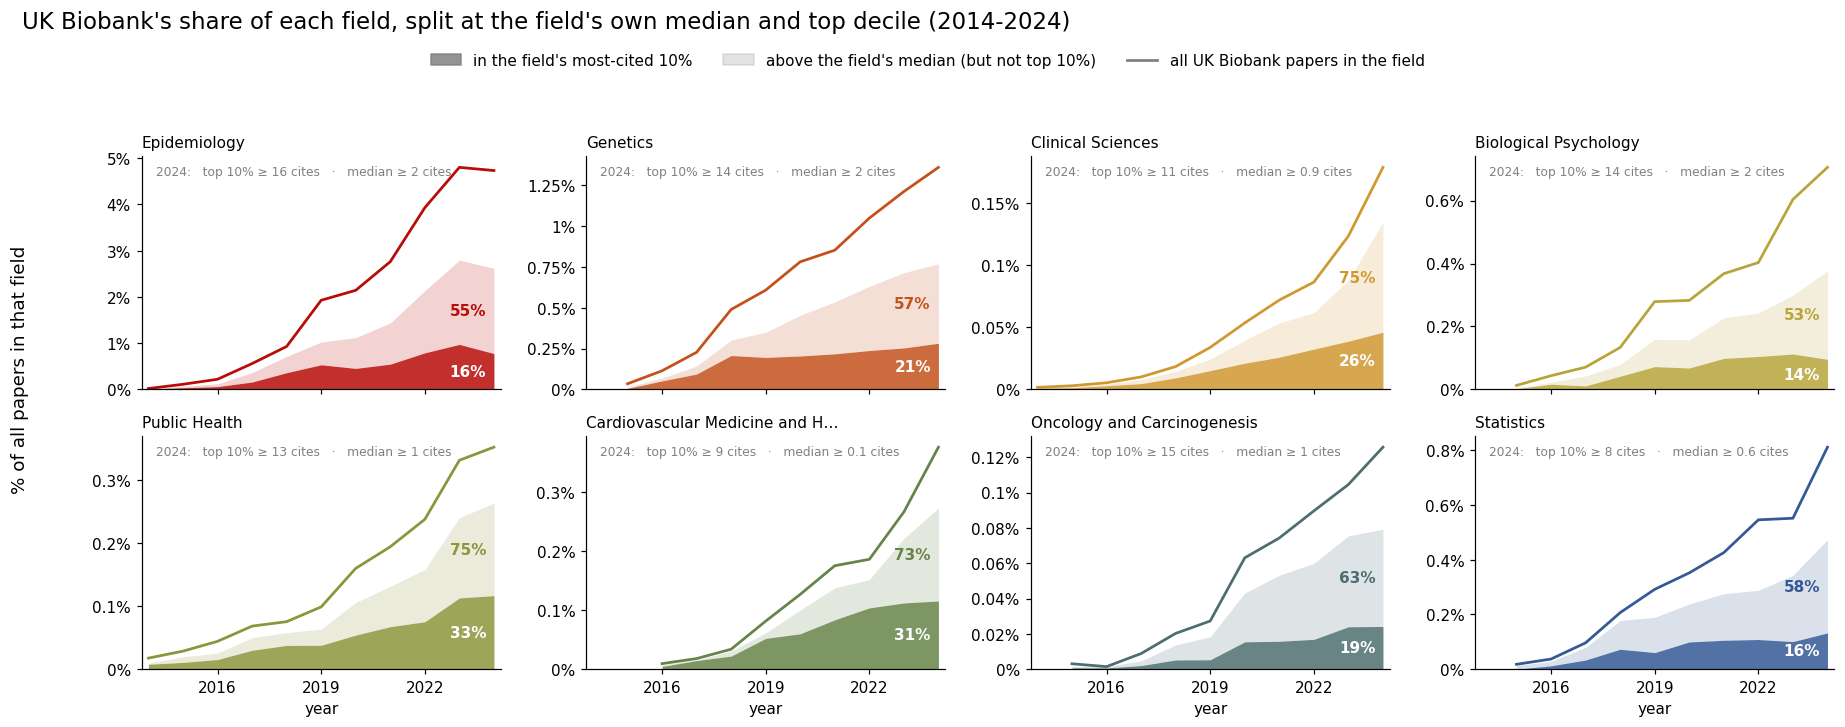

in 2024, of UK Biobank's papers in each field (an ordinary paper is above its field's median half the time, and in its top decile a tenth of the time):

  Epidemiology                      55.3% above the median ( 1.1x),  16.4% top decile ( 1.6x)
  Genetics                          56.6% above the median ( 1.1x),  20.8% top decile ( 2.1x)
  Clinical Sciences                 75.4% above the median ( 1.5x),  25.7% top decile ( 2.6x)
  Biological Psychology             53.4% above the median ( 1.1x),  13.6% top decile ( 1.4x)
  Public Health                     74.9% above the median ( 1.5x),  33.1% top decile ( 3.3x)
  Cardiovascular Medicine and Hae…  72.6% above the median ( 1.5x),  30.7% top decile ( 3.1x)
  Oncology and Carcinogenesis       63.0% above the median ( 1.3x),  19.2% top decile ( 1.9x)
  Statistics                        58.4% above the median ( 1.2x),  16.3% top decile ( 1.6x)


In [16]:
if TOP10_COL is None or TOP50_COL is None:
    print("chart 9a needs both cut-offs — the API pathway carries them "
          f"(top10={TOP10_COL}, median={TOP50_COL})")
else:
    _all = share_timeseries("n_papers")                             # the footprint
    _best = share_timeseries(TOP10_COL, denominator="n_papers")     # its top-decile part
    _half = share_timeseries(TOP50_COL, denominator="n_papers")     # its above-median part
    # A cell whose cut-off was never measured comes back as a zero count, not as a gap,
    # and zero here would draw as "none of its papers made the decile" — the opposite of
    # "we did not look". The _docs counters say which it is, so they are the mask: a band
    # is drawn only where the papers under it were actually scored against a cut-off.
    def _measured(column):
        return (ukbb[ukbb.code.isin(TOP_CODES)]
                .pivot_table(index="year", columns="code", values=f"{column}_docs",
                             aggfunc="sum").reindex(columns=TOP_CODES))
    _best = _best.where(_measured(TOP10_COL).reindex_like(_best) > 0)
    _half = _half.where(_measured(TOP50_COL).reindex_like(_half) > 0)
    _yrs = sorted(set(_all.index) & set(_best.index) & set(_half.index))
    _all, _best, _half = (f.loc[f.index.isin(_yrs)] for f in (_all, _best, _half))
    _drawn = []          # the years each panel could actually draw, for the title

    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.3 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        a, b, h = _all[code].dropna(), _best[code].dropna(), _half[code].dropna()
        idx = a.index.intersection(b.index).intersection(h.index)
        idx = contiguous_tail(idx)
        a, b, h = a.reindex(idx), b.reindex(idx), h.reindex(idx)
        # A paper above the decile is above the median too, so the bands nest; clip in
        # case a tie at the median cut-off makes the coarser count the smaller one.
        h = np.maximum(h, b)
        if not len(idx):
            continue
        _drawn += [int(idx[0]), int(idx[-1])]
        ax.fill_between(idx, 0, b, color=col, alpha=0.85, lw=0)
        ax.fill_between(idx, b, h, color=col, alpha=0.18, lw=0)
        ax.plot(idx, a, color=col, lw=1.8)
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        # Each share is written into the band it belongs to: white on the solid one,
        # the field's own colour on the pale one, which needs no legend lookup and no
        # second sentence explaining which number is which.
        if len(a) and a.iloc[-1] > 0:
            if b.iloc[-1] > 0:
                ax.annotate(f"{100 * b.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], b.iloc[-1] / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color="white", fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
            if h.iloc[-1] > b.iloc[-1]:
                ax.annotate(f"{100 * h.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], (h.iloc[-1] + b.iloc[-1]) / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color=col, fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
        ax.annotate(cut_note(code, idx[-1]), xy=(0.04, 0.96), xycoords="axes fraction",
                    ha="left", va="top", fontsize=STYLE["annot_fs"] - 1,
                    color=STYLE["edgecolor"])
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(min(_drawn), max(_drawn), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    # Neutral grey patches: the encoding is what the legend describes, and every panel
    # has its own colour for the field.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    # As in chart 9: the bands are read against the FIELD, the numbers written in them
    # against UK BIOBANK'S OWN output (an ordinary paper: 10% top-decile, 50% above the
    # median).
    fig.text(0.01, 0.905, f"numbers inside the bands are shares of UK Biobank's own "
             f"papers in that {UNIT} (ordinary: 10% top-decile, 50% above the median); "
             f"the axis is a share of the whole {UNIT}",
             fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"], ha="left", va="top")
    fig.legend(handles=[
        Patch(color=STYLE["edgecolor"], alpha=0.85,
              label="in the field's most-cited 10%"),
        Patch(color=STYLE["edgecolor"], alpha=0.22,
              label="above the field's median (but not top 10%)"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8,
               label="all UK Biobank papers in the field")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
        fontsize=STYLE["legend_fs"])
    fig.suptitle(f"UK Biobank's share of each {UNIT}, split at the {UNIT}'s own median "
                 f"and top decile ({min(_drawn)}-{max(_drawn)})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"% of all papers in that {UNIT}", fontsize=STYLE["label_fs"], x=0.004)
    flag_denominator(fig)
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    savefig(fig, f"09a_footprint_quality_median_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last = max(_drawn)
    print(f"in {_last}, of UK Biobank's papers in each {UNIT} (an ordinary paper is "
          f"above its field's median half the time, and in its top decile a tenth of "
          f"the time):\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        a = _all[code].get(_last, np.nan)
        b, h = _best[code].get(_last, np.nan), _half[code].get(_last, np.nan)
        if not (np.isfinite(a) and np.isfinite(h) and a > 0):
            continue
        print(f"  {short(lab, 32):32s} {100 * h / a:5.1f}% above the median "
              f"({100 * h / a / 50:4.1f}x), {100 * b / a:5.1f}% top decile "
              f"({100 * b / a / 10:4.1f}x)")

### 6.4 Chart 9b — Chart 9a with the cut-offs drawn on a second axis

Chart 9a says what share of UK Biobank's papers cleared each bar. It does not say **where the bar
was**, and the bar moves every year: a 2016 Epidemiology paper needed 59 citations to make the
field's top tenth, a 2024 one needs 16. Read without that, the fall in the solid band after 2022
looks like a fall in quality, when the cut-off is simply still filling in for papers a year old.

| axis | what it shows |
|---|---|
| **left (bands)** | exactly Chart 9a: solid = top decile, pale = above the median, line = UK Biobank's whole share of the field |
| **right (dashes)** | what those two cut-offs were, **in citations**, in the same year: dashed = top-decile cut-off, dotted = median |

The right axis is a different quantity in different units, so it is drawn in grey and never
filled — **nothing on it is meant to be compared to the bands by height**. What it is for is the
*shape*: both cut-offs decay to the right at much the same rate in every field, which is the
citation clock, and the bands do not follow them down. That is the argument this chart makes and
9a cannot.

*Saves as* `09b_footprint_quality_cutoffs_…`


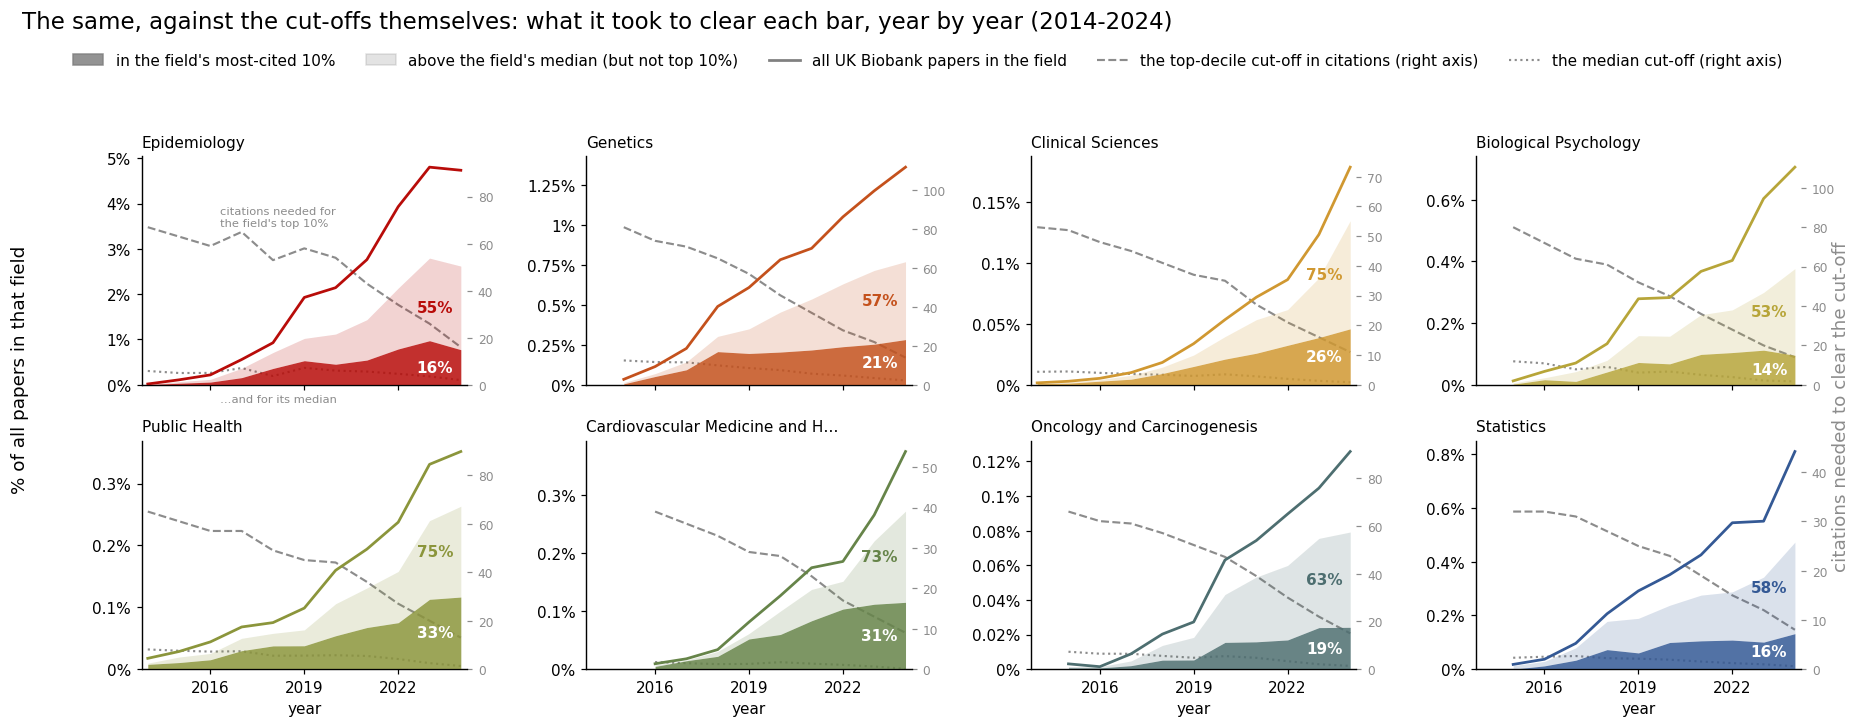

what it took to clear each bar, 2014 vs 2024 (a 2024 paper has had one year to collect citations, a 2014 one 10):

  Epidemiology                     top 10%:   67 ->   16 cites    median:    6 ->    2
  Clinical Sciences                top 10%:   53 ->   11 cites    median:    4 ->  0.9
  Public Health                    top 10%:   65 ->   13 cites    median:    8 ->    1


In [17]:
if TOP10_COL is None or TOP50_COL is None or CUTS is None:
    print("chart 9b needs both cut-offs — the API pathway carries them "
          f"(top10={TOP10_COL}, median={TOP50_COL})")
else:
    _all = share_timeseries("n_papers")                             # the footprint
    _best = share_timeseries(TOP10_COL, denominator="n_papers")     # its top-decile part
    _half = share_timeseries(TOP50_COL, denominator="n_papers")     # its above-median part
    # A cell whose cut-off was never measured comes back as a zero count, not as a gap,
    # and zero here would draw as "none of its papers made the decile" — the opposite of
    # "we did not look". The _docs counters say which it is, so they are the mask: a band
    # is drawn only where the papers under it were actually scored against a cut-off.
    def _measured(column):
        return (ukbb[ukbb.code.isin(TOP_CODES)]
                .pivot_table(index="year", columns="code", values=f"{column}_docs",
                             aggfunc="sum").reindex(columns=TOP_CODES))
    _best = _best.where(_measured(TOP10_COL).reindex_like(_best) > 0)
    _half = _half.where(_measured(TOP50_COL).reindex_like(_half) > 0)
    _yrs = sorted(set(_all.index) & set(_best.index) & set(_half.index))
    _all, _best, _half = (f.loc[f.index.isin(_yrs)] for f in (_all, _best, _half))
    _drawn = []          # the years each panel could actually draw, for the title

    C_CUT = "#8C8C8C"      # the cut-off axis: grey, because it is not the subject
    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.3 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        a, b, h = _all[code].dropna(), _best[code].dropna(), _half[code].dropna()
        idx = a.index.intersection(b.index).intersection(h.index)
        idx = contiguous_tail(idx)
        a, b, h = a.reindex(idx), b.reindex(idx), h.reindex(idx)
        # A paper above the decile is above the median too, so the bands nest; clip in
        # case a tie at the median cut-off makes the coarser count the smaller one.
        h = np.maximum(h, b)
        if not len(idx):
            continue
        _drawn += [int(idx[0]), int(idx[-1])]
        ax.fill_between(idx, 0, b, color=col, alpha=0.85, lw=0)
        ax.fill_between(idx, b, h, color=col, alpha=0.18, lw=0)
        ax.plot(idx, a, color=col, lw=1.8)
        # ---- the cut-offs themselves, in citations, on their own axis -------------
        _c = CUTS.reindex([(int(y), code) for y in idx])
        axc = ax.twinx()
        axc.plot(idx, _c.thr10.to_numpy(), color=C_CUT, lw=1.4, ls="--")
        axc.plot(idx, _c["median"].to_numpy(), color=C_CUT, lw=1.4, ls=":")
        # Anchored at zero and headroom above the decile line, so the median line is not
        # squashed onto the axis and neither can be mistaken for one of the bands.
        axc.set_ylim(0, float(np.nanmax(_c.thr10.to_numpy())) * 1.45)
        axc.tick_params(labelsize=STYLE["annot_fs"] - 1, colors=C_CUT)
        axc.spines["right"].set_color(C_CUT)
        if code == TOP_CODES[0]:
            _m = min(2, len(idx) - 1)
            axc.annotate("citations needed for\nthe field's top 10%",
                         xy=(idx[_m], float(_c.thr10.iloc[_m])), xytext=(6, 12),
                         textcoords="offset points", ha="left", va="bottom",
                         fontsize=STYLE["annot_fs"] - 1.5, color=C_CUT)
            axc.annotate("…and for its median",
                         xy=(idx[_m], float(_c["median"].iloc[_m])), xytext=(6, -14),
                         textcoords="offset points", ha="left", va="top",
                         fontsize=STYLE["annot_fs"] - 1.5, color=C_CUT)
        ax.set_zorder(axc.get_zorder() + 1)   # keep the bands' labels above the dashes
        ax.patch.set_visible(False)
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        # Each share is written into the band it belongs to: white on the solid one,
        # the field's own colour on the pale one, which needs no legend lookup and no
        # second sentence explaining which number is which.
        if len(a) and a.iloc[-1] > 0:
            if b.iloc[-1] > 0:
                ax.annotate(f"{100 * b.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], b.iloc[-1] / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color="white", fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
            if h.iloc[-1] > b.iloc[-1]:
                ax.annotate(f"{100 * h.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], (h.iloc[-1] + b.iloc[-1]) / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color=col, fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(min(_drawn), max(_drawn), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    # Neutral grey patches: the encoding is what the legend describes, and every panel
    # has its own colour for the field.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Patch(color=STYLE["edgecolor"], alpha=0.85,
              label="in the field's most-cited 10%"),
        Patch(color=STYLE["edgecolor"], alpha=0.22,
              label="above the field's median (but not top 10%)"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8,
               label="all UK Biobank papers in the field"),
        Line2D([], [], color="#8C8C8C", lw=1.4, ls="--",
               label="the top-decile cut-off in citations (right axis)"),
        Line2D([], [], color="#8C8C8C", lw=1.4, ls=":",
               label="the median cut-off (right axis)")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=5, frameon=False,
        fontsize=STYLE["legend_fs"])
    fig.suptitle(f"The same, against the cut-offs themselves: what it took to clear each "
                 f"bar, year by year ({min(_drawn)}-{max(_drawn)})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"% of all papers in that {UNIT}", fontsize=STYLE["label_fs"], x=0.004)
    flag_denominator(fig)
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    fig.text(0.999, 0.45, "citations needed to clear the cut-off", rotation=90,
             va="center", ha="right", fontsize=STYLE["label_fs"], color=C_CUT)
    savefig(fig, f"09b_footprint_quality_cutoffs_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last, _first = max(_drawn), min(_drawn)
    print(f"what it took to clear each bar, {_first} vs {_last} "
          f"(a {_last} paper has had one year to collect citations, a {_first} one "
          f"{_last - _first}):\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        r0 = CUTS.reindex([(_first, code)]).iloc[0]
        r1 = CUTS.reindex([(_last, code)]).iloc[0]
        if r0.thr10 != r0.thr10 or r1.thr10 != r1.thr10:
            continue
        print(f"  {short(lab, 32):32s} top 10%: {_cit(r0.thr10):>4s} -> "
              f"{_cit(r1.thr10):>4s} cites    median: {_cit(r0['median']):>4s} -> "
              f"{_cit(r1['median']):>4s}")

### 6.5 Chart 10 — The field's top-cited pool, and UK Biobank in it

Chart 9 divides by the **field**: of all the papers published in Epidemiology, what share is UK
Biobank's, and how good is it? This divides by the **top decile**: of the papers that made the
field's most-cited tenth, how many are there in the first place, and how many of them are UK
Biobank's?

| | |
|---|---|
| **bar height** | every paper in the world that made this field's top decile that year |
| **coloured foot** | UK Biobank's papers among them |
| **line** | that foot as a **percentage** of the bar (right axis) |

The line is not decoration. UK Biobank's share of these pools runs from 0.2% to 10%, a fiftyfold
spread, so at a common bar scale the coloured foot is a visible block in Epidemiology and a
hairline in Clinical Sciences — true, and unreadable. The line puts all eight panels on a scale
where the trend can be read; the foot keeps the reader honest about how small the absolute
contribution still is in the big fields.

**What the bar is and is not.** It is the count of papers at or above the measured decile cut-off
for that (year, field) — so it is ~10% of the field's papers by construction, and its **growth is
the field's growth**, not a change in standards. What moves between panels is the pool's size
(Clinical Sciences puts 65,000 papers a year into its own top tenth; Epidemiology 2,200), which
is the context Chart 9's percentages do not carry. Years before the cut-off was measured are
absent rather than zero.

*Saves as* `10_top_decile_pool_…`


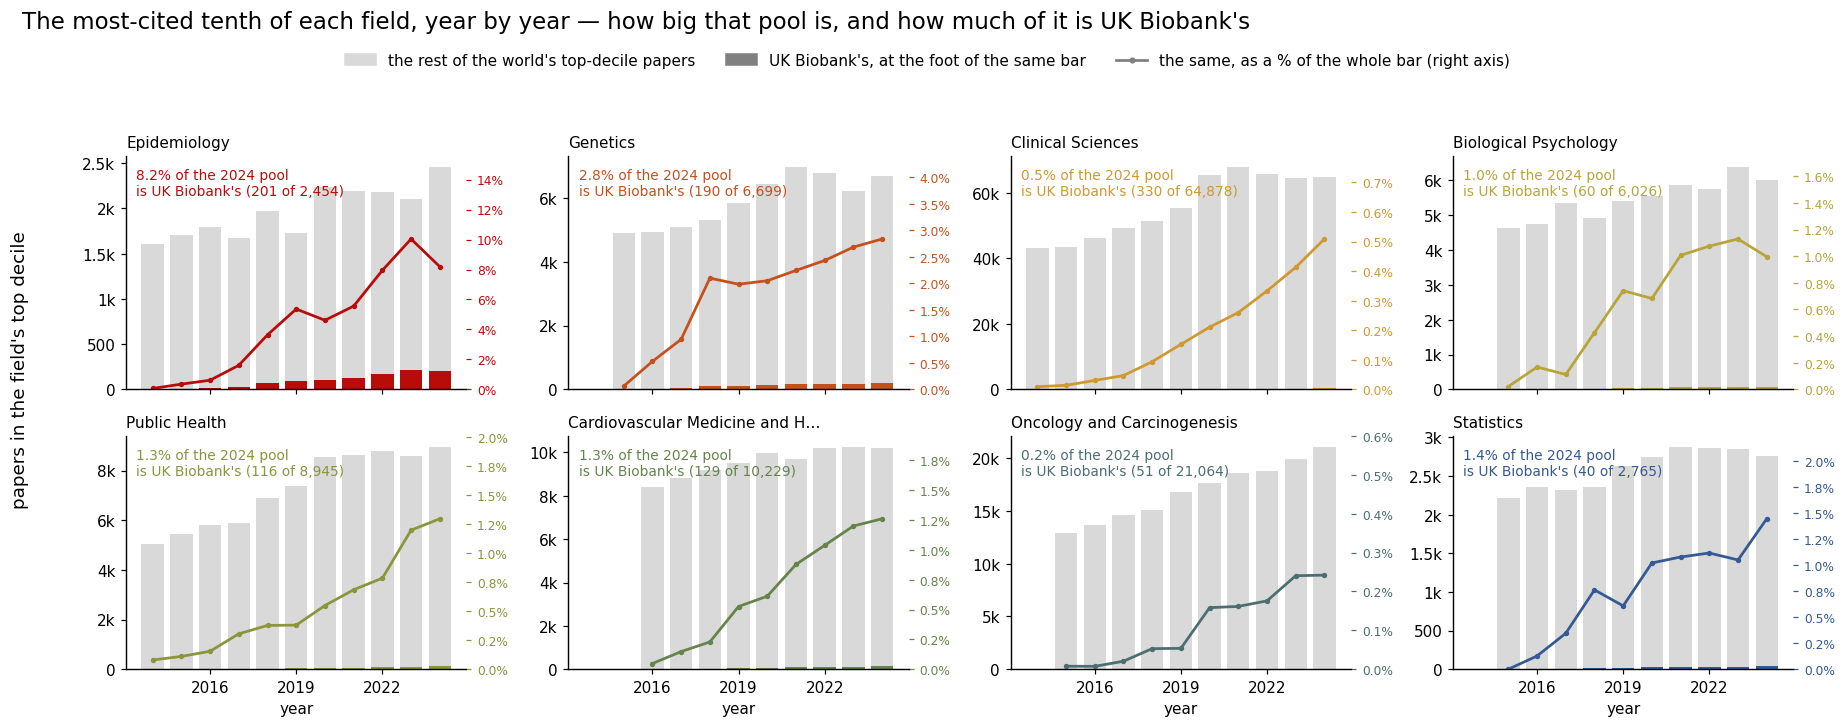


UK Biobank inside each field's most-cited tenth (the pool is ~10% of the field by construction, so its size is the field's size):


,pool@2024,ukbb@2024,ukbb_%@2024,measured_from,ukbb_%_then,x_since
field,,,,,,
Epidemiology,2454,201,8.19,2014,0.06,131.7
Genetics,6699,190,2.84,2015,0.06,46.2
Clinical Sciences,64878,330,0.51,2014,0.01,55.0
Biological Psychology,6026,60,1.00,2015,0.02,46.2
Public Health,8945,116,1.30,2014,0.08,16.4
Cardiovascular Medicine and Haema…,10229,129,1.26,2016,0.05,26.5
Oncology and Carcinogenesis,21064,51,0.24,2015,0.01,31.3
Statistics,2765,40,1.45,2015,0.00,NaN


In [18]:
if TOP10_COL is None:
    print("no top-decile column — VM: --weights top10,top10f; API: the `deciles` mode")
else:
    def _pool(frame, column):
        return (frame[frame.code.isin(TOP_CODES)]
                .pivot_table(index="year", columns="code", values=column, aggfunc="sum")
                .reindex(columns=TOP_CODES))
    _w10 = _pool(whole, TOP10_COL).where(_pool(whole, f"{TOP10_COL}_docs") > 0)
    _u10 = _pool(ukbb, TOP10_COL).where(_pool(ukbb, f"{TOP10_COL}_docs") > 0)
    _u10 = _u10.reindex_like(_w10)
    _shr = (_u10 / _w10.where(_w10 > 0) * 100)

    C_POOL = "#D9D9D9"       # the world's papers: present, deliberately quiet
    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.3 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:g}k" if x >= 1000 else f"{x:g}")

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        pool = _w10[code].dropna()
        if not len(pool):
            continue
        ukb = _u10[code].reindex(pool.index).fillna(0.0)
        ax.bar(pool.index, pool.values - ukb.values, bottom=ukb.values, color=C_POOL,
               width=0.78, lw=0)
        ax.bar(pool.index, ukb.values, color=col, width=0.78, lw=0)
        ax.set_title(short(lab, 30), fontsize=STYLE["annot_fs"] + 1, loc="left")
        ax.yaxis.set_major_formatter(kfmt)
        ax.set_ylim(bottom=0)
        ax.margins(x=0.03)

        # Right axis: the same two numbers as one ratio, which is the only form in which
        # all eight panels are comparable.
        axp = ax.twinx()
        s = _shr[code].reindex(pool.index)
        axp.plot(s.index, s.values, color=col, lw=1.8, marker="o", ms=2.5)
        axp.set_ylim(0, max(float(np.nanmax(s.values)) * 1.55, 0.6))
        axp.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"
                                      if np.nanmax(s.values) >= 3 else "{x:.1f}%"))
        axp.tick_params(labelsize=STYLE["annot_fs"] - 1, colors=col)
        axp.spines["right"].set_color(col)
        if s.notna().any():
            _l = s.dropna()
            axp.annotate(f"{_l.iloc[-1]:.1f}% of the {int(_l.index[-1])} pool\n"
                         f"is UK Biobank's ({int(ukb.iloc[-1]):,} of "
                         f"{int(pool.iloc[-1]):,})",
                         xy=(0.03, 0.95), xycoords="axes fraction", ha="left", va="top",
                         fontsize=STYLE["annot_fs"], color=col)
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(_w10.dropna(how='all').index.min(), _w10.dropna(how='all').index.max(), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Patch(color=C_POOL, label="the rest of the world's top-decile papers"),
        Patch(color=STYLE["edgecolor"], label="UK Biobank's, at the foot of the same bar"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8, marker="o", ms=3,
               label="the same, as a % of the whole bar (right axis)")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
        fontsize=STYLE["legend_fs"])
    fig.suptitle(f"The most-cited tenth of each {UNIT}, year by year — how big that pool "
                 f"is, and how much of it is UK Biobank's",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"papers in the {UNIT}'s top decile", fontsize=STYLE["label_fs"],
                  x=0.004)
    flag_denominator(fig)
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    savefig(fig, f"10_top_decile_pool_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    # One row per field. The first measured year differs by field (a decile cut-off is
    # only measured where UK Biobank had papers to place against it), so it is a COLUMN
    # rather than part of the header — otherwise the table comes out ragged.
    _rows = []
    _end = int(max(_shr[c].dropna().index[-1] for c in TOP_CODES if _shr[c].notna().any()))
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        s = _shr[code].dropna()
        if not len(s):
            continue
        _rows.append({UNIT: short(lab, 34),
                      f"pool@{_end}": int(_w10.loc[_end, code]),
                      f"ukbb@{_end}": int(_u10.loc[_end, code]),
                      f"ukbb_%@{_end}": round(float(s.loc[_end]), 2),
                      "measured_from": int(s.index[0]),
                      "ukbb_%_then": round(float(s.iloc[0]), 2),
                      "x_since": round(float(s.loc[_end] / s.iloc[0]), 1)
                      if s.iloc[0] > 0 else np.nan})
    print(f"\nUK Biobank inside each {UNIT}'s most-cited tenth "
          f"(the pool is ~10% of the {UNIT} by construction, so its size is the "
          f"{UNIT}'s size):")
    display(pd.DataFrame(_rows).set_index(UNIT))

## 7. Growth — where UK Biobank is growing fastest, and whether the world is too

### Chart 11 — Fastest-growing fields, against the same fields in the whole database

Every chart so far ranks fields by **size**: UK Biobank's biggest eight, followed through the
database. That ranking is stable by construction — Epidemiology and Clinical Sciences were the
biggest in 2016 and will be in 2026 — so it cannot show a field *arriving*. This one ranks by
**speed** instead, and drops the size filter: a field that went from 6 papers to 126 belongs here
beside one that went from 350 to 1,283.

**Two rates per field, measured the same way in both arms:**

* **growth** — the compound annual rate over `GROW_NOW`. 30%/yr means "a third bigger every year",
  and compounds to 2.9× over four years.
* **acceleration** — that rate minus the same rate over `GROW_PREV`, in percentage points per
  year. Positive = speeding up.

**Read the acceleration column with one fact in mind.** UK Biobank's own output was doubling
annually in the late 2010s from a base of almost nothing, so nearly every field decelerates
against that window; the number says "growing less explosively than during the ramp-up", not
"shrinking". The fields that accelerate anyway — Metabolomics, Allied Health — are doing something
genuinely new. The honest reference for "is this field gaining ground **inside** UK Biobank" is the
dashed line on the left panel: UK Biobank's own total growth rate. A field to its right is taking a
bigger share of the portfolio every year; one to its left is being diluted, however fast it grows.

**What the comparison with the world is for.** The hollow marker is the same field's growth in the
whole database. Most of these fields grow at 2–10%/yr out there, so the gap between the markers is
**UK Biobank moving into a field** rather than the field itself taking off. Neurosciences is the
sharpest case: the world's output is flat (−0.2%/yr) while UK Biobank's grows 47%/yr.

*Saves as* `11_fastest_growing_…`


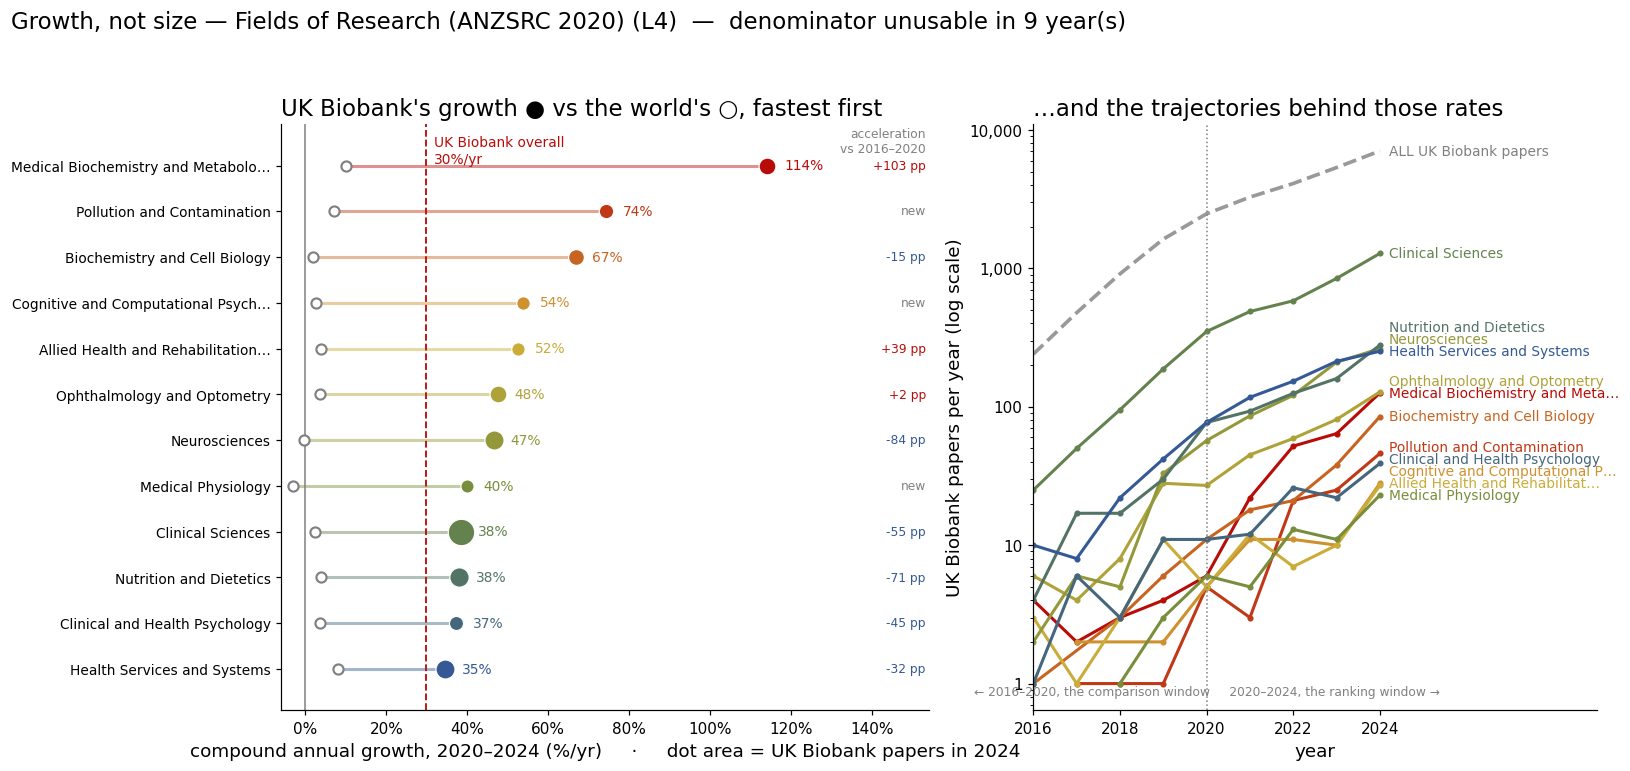

fastest-growing fields inside UK Biobank, 2020-2024 (ranked on speed alone; floors of 5 papers in 2020 and 20 in 2024).
UK Biobank overall grew 30%/yr over the same window:


,ukbb@2024,ukbb_%/yr,ukbb_accel_pp,world_%/yr,world_accel_pp,activity_x
field,,,,,,
Medical Biochemistry and Metabolomics,126,114.1,103.4,10.1,-1.7,3.2
Pollution and Contamination,46,74.2,NaN,7.1,-4.8,3.1
Biochemistry and Cell Biology,85,66.7,-15.4,1.9,-3.6,0.1
Cognitive and Computational Psychology,28,53.8,NaN,2.5,-3.3,0.3
Allied Health and Rehabilitation Science,27,52.4,38.8,3.9,-4.0,0.1
Ophthalmology and Optometry,128,47.6,1.9,3.7,-3.6,1.3
Neurosciences,263,46.6,-84.5,-0.2,-2.8,2.0
Medical Physiology,23,39.9,NaN,-2.9,-3.2,0.3
Clinical Sciences,1283,38.4,-55.1,2.3,-6.4,0.9


In [19]:
GROW_NOW  = (YEAR_MAX - 4, YEAR_MAX)     # the window the ranking is on
GROW_PREV = (YEAR_MAX - 8, YEAR_MAX - 4)  # the window it is compared against
GROW_TOP_M = 12         # how many fields to draw
# Speed is the only ranking criterion, but a rate needs a denominator that is not noise:
# 2 papers -> 8 is 400% and means nothing. These floors are as low as they can be while
# keeping that out, and they are the ONLY size condition anywhere in this chart.
GROW_MIN_BASE = 5       # UK Biobank papers in the base year
GROW_MIN_LAST = 20      # UK Biobank papers in the final year

_uts = ukbb.pivot_table(index="year", columns="code", values="n_papers", aggfunc="sum")
_wts = whole.pivot_table(index="year", columns="code", values="n_papers",
                         aggfunc="sum").reindex(columns=_uts.columns)

def _cagr(frame, win):
    """Compound annual growth between the endpoints of `win`, as %/yr."""
    (a, b) = win
    if a not in frame.index or b not in frame.index:
        return pd.Series(np.nan, index=frame.columns)
    lo, hi = frame.loc[a].replace(0, np.nan), frame.loc[b].replace(0, np.nan)
    return ((hi / lo) ** (1.0 / (b - a)) - 1.0) * 100

_ok = ((_uts.loc[GROW_NOW[0]].fillna(0) >= GROW_MIN_BASE)
       & (_uts.loc[GROW_NOW[1]].fillna(0) >= GROW_MIN_LAST))
# ACTIVITY is keyed on every code the run has, not just these, so every column is
# reindexed onto the UK Biobank arm's codes before the frame is built.
_codes = _uts.columns
GROWTH = (pd.DataFrame({
    "ukbb_now": _cagr(_uts, GROW_NOW), "ukbb_prev": _cagr(_uts, GROW_PREV),
    "world_now": _cagr(_wts, GROW_NOW), "world_prev": _cagr(_wts, GROW_PREV),
    "ukbb_papers": _uts.loc[GROW_NOW[1]], "world_papers": _wts.loc[GROW_NOW[1]],
    "activity_x": pd.Series(ACTIVITY).reindex(_codes)}, index=_codes)
    [_ok.reindex(_codes).fillna(False)]
    .assign(accel=lambda d: d.ukbb_now - d.ukbb_prev,
            world_accel=lambda d: d.world_now - d.world_prev)
    .sort_values("ukbb_now", ascending=False))
GROWTH.index = pd.Index([CODE_LABEL.get(c, c) for c in GROWTH.index], name=UNIT)

# UK Biobank's own pace over the same window: the line that separates "gaining share of
# the portfolio" from "growing, but slower than the resource as a whole".
_tot = ukbb.groupby("year").n_papers.sum()
UKBB_PACE = float((_tot[GROW_NOW[1]] / _tot[GROW_NOW[0]]) ** (1 / (GROW_NOW[1] - GROW_NOW[0])) - 1) * 100

_top = GROWTH.head(GROW_TOP_M)
# These are not the top-N fields the rest of the notebook colours, so the palette is
# local to this chart; using FIELD_COLORS would give two different fields one colour.
_cols = dict(zip(_top.index, extended_palette(len(_top))))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# ---- left: world rate -> UK Biobank rate, one row per field ----------------------
ypos = np.arange(len(_top))[::-1]        # fastest at the top
for y, (lab, r) in zip(ypos, _top.iterrows()):
    col = _cols[lab]
    axL.plot([r.world_now, r.ukbb_now], [y, y], color=col, lw=2, alpha=0.45,
             zorder=2, solid_capstyle="round")
    axL.scatter(r.world_now, y, s=44, facecolor="white", edgecolor=STYLE["edgecolor"],
                linewidth=1.4, zorder=3)
    axL.scatter(r.ukbb_now, y, s=40 + 260 * np.sqrt(r.ukbb_papers / _top.ukbb_papers.max()),
                color=col, edgecolor="white", linewidth=0.8, zorder=4)
    axL.annotate(f"{r.ukbb_now:.0f}%", (r.ukbb_now, y), xytext=(11, 0),
                 textcoords="offset points", va="center", fontsize=STYLE["annot_fs"],
                 color=col)
axL.axvline(0, color=STYLE["edgecolor"], lw=1)
axL.axvline(UKBB_PACE, color=STYLE["colors"][0], lw=1.2, ls="--")
axL.annotate(f"UK Biobank overall\n{UKBB_PACE:.0f}%/yr", (UKBB_PACE, len(_top) - 0.35),
             xytext=(5, 0), textcoords="offset points", va="top",
             fontsize=STYLE["annot_fs"], color=STYLE["colors"][0])
axL.set_yticks(ypos)
axL.set_yticklabels([short(l, 34) for l in _top.index], fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.9, len(_top) - 0.1)
axL.set_xlim(min(-3, _top.world_now.min() - 3), _top.ukbb_now.max() * 1.35)
axL.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"))
axL.set_xlabel(f"compound annual growth, {GROW_NOW[0]}–{GROW_NOW[1]} (%/yr)"
               f"     ·     dot area = UK Biobank papers in {GROW_NOW[1]}")
axL.set_title(f"UK Biobank's growth ● vs the world's ○, fastest first",
              loc="left", fontsize=STYLE["title_fs"])

# The acceleration is a second measure, so it gets its own column rather than a second
# glyph on a row that already carries three.
_xa = axL.get_xlim()[1]
axL.annotate(f"acceleration\nvs {GROW_PREV[0]}–{GROW_PREV[1]}", (0.995, 0.995),
             xycoords="axes fraction", ha="right", va="top",
             fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"])
for y, (lab, r) in zip(ypos, _top.iterrows()):
    if r.accel != r.accel:
        txt, c = "new", STYLE["edgecolor"]
    else:
        txt = f"{r.accel:+.0f} pp"
        c = STYLE["colors"][0] if r.accel > 0 else STYLE["colors"][3]
    axL.annotate(txt, (0.995, y), xycoords=("axes fraction", "data"), ha="right",
                 va="center", fontsize=STYLE["annot_fs"] - 1, color=c)

# ---- right: the trajectories those rates summarise -------------------------------
# Absolute counts on a log axis: the SLOPE is the growth rate, so parallel lines grow
# equally fast whatever their size, and a small fast field is legible beside a large one
# instead of being flattened onto the axis.
_span = range(GROW_PREV[0], GROW_NOW[1] + 1)
_lab_at = []
for lab, r in _top.iterrows():
    code = next(c for c in _uts.columns if CODE_LABEL.get(c, c) == lab)
    s = _uts[code].reindex(_span).replace(0, np.nan).dropna()
    axR.plot(s.index, s.values, color=_cols[lab], lw=2, marker="o", ms=3)
    _lab_at.append((float(s.iloc[-1]), lab))
_all_ukbb = _tot.reindex(_span)
axR.plot(_all_ukbb.index, _all_ukbb.values, color=STYLE["edgecolor"], lw=2.4, ls="--",
         alpha=0.8)
_lab_at.append((float(_all_ukbb.iloc[-1]), "ALL UK Biobank papers"))

# Direct labels beat a 13-entry legend, but several series end within a few percent of
# each other; nudge them apart in log space so every label stays readable.
_lo, _hi = min(v for v, _ in _lab_at), max(v for v, _ in _lab_at)
_gap = 0.030 * (np.log10(_hi / _lo) + 0.4)
_prev = None
for value, lab in sorted(_lab_at):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (GROW_NOW[1], 10 ** ly),
                 color=_cols.get(lab, STYLE["edgecolor"]), fontsize=STYLE["annot_fs"],
                 va="center", xytext=(6, 0), textcoords="offset points")
axR.set_yscale("log")
axR.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
axR.axvline(GROW_NOW[0], color=STYLE["edgecolor"], ls=":", lw=1)
axR.annotate(f"← {GROW_PREV[0]}–{GROW_PREV[1]}, the comparison window     "
             f"{GROW_NOW[0]}–{GROW_NOW[1]}, the ranking window →",
             (GROW_NOW[0], 0.02), xycoords=("data", "axes fraction"), ha="center",
             va="bottom", fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"])
axR.set_xlim(GROW_PREV[0], GROW_NOW[1] + 5)
axR.set_xticks(year_ticks(GROW_PREV[0], GROW_NOW[1], 2))
axR.set_xlabel("year")
axR.set_ylabel("UK Biobank papers per year (log scale)")
axR.set_title("…and the trajectories behind those rates", loc="left",
              fontsize=STYLE["title_fs"])

fig.suptitle(f"Growth, not size — {SYSTEM} ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
flag_denominator(axR)
fig.tight_layout(rect=(0, 0, 1, 0.955))
savefig(fig, f"11_fastest_growing_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

_show = (_top[["ukbb_papers", "ukbb_now", "accel", "world_now", "world_accel",
               "activity_x"]]
         .rename(columns={"ukbb_papers": f"ukbb@{GROW_NOW[1]}",
                          "ukbb_now": f"ukbb_%/yr", "accel": "ukbb_accel_pp",
                          "world_now": "world_%/yr", "world_accel": "world_accel_pp",
                          "activity_x": "activity_x"}).round(1))
_show[f"ukbb@{GROW_NOW[1]}"] = _show[f"ukbb@{GROW_NOW[1]}"].astype(int)
print(f"fastest-growing {UNIT}s inside UK Biobank, {GROW_NOW[0]}-{GROW_NOW[1]} "
      f"(ranked on speed alone; floors of {GROW_MIN_BASE} papers in {GROW_NOW[0]} and "
      f"{GROW_MIN_LAST} in {GROW_NOW[1]}).\nUK Biobank overall grew {UKBB_PACE:.0f}%/yr "
      f"over the same window:")
display(_show)